# CafeTrace. Pipeline de aprendizaje automatico y modelo de optimizacion

Cuaderno de punta a punta para el eje de trazabilidad, calidad y
verificacion de cafe organico de exportacion.

## Que problema resuelve

Un lote de cafe declarado organico puede llegar contaminado por
agroquimicos sin que nadie lo sepa hasta la aduana de destino. Cuando eso
pasa, la penalizacion de referencia es de cincuenta dolares por quintal y
el riesgo real es la descertificacion de toda la cooperativa. El unico
momento en que la perdida todavia se puede evitar es el centro de acopio,
antes de consolidar el contenedor.

El problema tiene dos mitades y este cuaderno las resuelve en cadena:

1. **Prediccion.** Estimar la probabilidad de que un lote este contaminado
   usando solo lo que se observa antes de correr el kit: geometria de la
   parcela, meteorologia de la ventana de aplicacion y practicas de
   beneficio declaradas en el cuaderno de campo.
2. **Decision.** Convertir esas probabilidades en un plan de segregacion
   que maximice el valor comercial sin exceder la tolerancia de riesgo que
   acepta el comprador para el contenedor.

## Prioridad de la metrica

La metrica principal es F1, pero con prioridad explicita al recall. La
asimetria de costos lo justifica: un falso positivo manda a mercado
convencional un lote que estaba limpio y cuesta la diferencia de precio; un
falso negativo embarca un lote contaminado y cuesta la penalizacion, el
contenedor completo y la certificacion. Por eso el umbral operativo no se
elige donde F1 es maximo en terminos absolutos, sino donde F1 es maximo
entre los umbrales que alcanzan un piso de recall.

## Estructura del cuaderno

1. Configuracion y parametros
2. Ingesta y cruce de tablas con DuckDB
3. Analisis exploratorio
4. Preparacion de variables: escalado, bucketizacion y codificacion
5. Particion temporal
6. Primer entrenamiento: filtrado por varianza y correlacion
7. Segundo entrenamiento: filtrado por valores SHAP
8. Tercer entrenamiento: refinamiento numerico y categorico
9. Umbral operativo y calibracion isotonica
10. Validacion por deciles
11. Modelo multietiqueta por agroquimico
12. Modelo de optimizacion entera mixta
13. Guardado de resultados

## 1. Configuracion y parametros

Todo lo que se puede discutir con el area de negocio vive en esta celda.
Nada mas abajo tiene numeros magicos escondidos.

In [1]:
import gc
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

warnings.filterwarnings("ignore")

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
CLEAN = RAIZ / "data" / "clean"
RESULTADOS = RAIZ / "resultados"

for sub in ["eda", "modelo", "optimizacion"]:
    (RESULTADOS / sub).mkdir(parents=True, exist_ok=True)

SEMILLA = 20260829
np.random.seed(SEMILLA)

# Particion temporal. Se entrena con campanas pasadas y se evalua con la
# campana siguiente, que es exactamente como se usaria en produccion.
CORTE_CALIBRACION = "2026-04-01"
CORTE_PRUEBA = "2026-07-01"

# Piso de recall sobre el conjunto de calibracion. Entre los umbrales que
# lo alcanzan se elige el de mayor F1.
RECALL_MINIMO = 0.80

# Umbral de valor de informacion para conservar una variable numerica.
IV_MINIMO = 0.02

# Cobertura de importancia SHAP acumulada que se retiene en la etapa dos.
COBERTURA_SHAP = 0.95

# Parametros economicos del modelo de optimizacion, en dolares por quintal.
PRECIO_ORGANICO = 210.0
PRECIO_CONVENCIONAL = 160.0

# Costo por unidad de probabilidad de contaminacion de un lote exportado.
# Incluye la penalizacion de cincuenta dolares por quintal mas el arrastre
# sobre el resto del contenedor y el costo de auditoria. El punto de
# indiferencia queda en una probabilidad de 50 sobre 260, es decir 0.192.
LAMBDA_RIESGO = 260.0

# Tolerancia de riesgo del contenedor de exportacion.
ALFA_CONTENEDOR = 0.05

# Probabilidad a partir de la cual una finca se declara foco y sus vecinas
# quedan en cuarentena, y radio de esa vecindad en metros.
P_CUARENTENA = 0.80
RADIO_CUARENTENA_M = 800.0

PALETA = ["#4f6640", "#c0392b", "#e0a80b", "#6b7f4e", "#8d8d84", "#3f8f5f"]
sns.set_theme(style="whitegrid", palette=PALETA, font_scale=0.95)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.bbox"] = "tight"

print("raiz     ", RAIZ)
print("semilla  ", SEMILLA)
print("particion", CORTE_CALIBRACION, CORTE_PRUEBA)

raiz      /home/germain/Documentos/Python_Projects/Disrupton
semilla   20260829
particion 2026-04-01 2026-07-01


## 2. Ingesta y cruce de tablas

Las tres fuentes de datos llegan por caminos distintos y con
granularidades distintas:

* La aplicacion de campo entrega un registro por lote cosechado.
* Las interfaces externas entregan una serie meteorologica diaria por
  finca y una capa geografica estatica.
* El laboratorio entrega un resultado por muestra y por kit.

El cruce se hace con DuckDB directamente sobre los CSV de la capa
procesada. DuckDB lee el archivo columna por columna y resuelve las
uniones sin materializar tablas intermedias en memoria, que es justo lo
que hace falta cuando la serie meteorologica tiene dos ordenes de magnitud
mas filas que la tabla de lotes. Una vez consolidada la tabla ancha, que
cabe holgadamente en memoria, se pasa a pandas para el modelado y se
libera con el recolector de basura todo lo que ya no se usa.

Nota sobre la union de la meteorologia. La tabla ya viene resumida en la
ventana de quince dias previos a la cosecha, que es el periodo en el que la
aplicacion del vecino puede alcanzar al lote. Cruzar el clima del dia de
la entrega no tendria sentido fisico.

In [2]:
import duckdb

consulta = f"""
WITH lotes AS (
    SELECT * FROM read_csv_auto('{CLEAN}/app/lotes.csv')
),
campo AS (
    SELECT * FROM read_csv_auto('{CLEAN}/app/registros_campo.csv')
),
gis AS (
    SELECT * FROM read_csv_auto('{CLEAN}/apis/gis_fincas.csv')
),
meteo AS (
    SELECT * FROM read_csv_auto('{CLEAN}/apis/meteo_ventana.csv')
),
elisa AS (
    SELECT * FROM read_csv_auto('{CLEAN}/elisa/elisa_lote.csv')
)
SELECT
    l.lote_id, l.finca_id, l.fecha_cosecha, l.peso_quintales,
    l.variedad, l.destino_previsto, l.dias_secado_patio,

    c.tecnico_id, c.vecino_fumigo_reciente, c.dias_desde_fumigacion_vecina,
    c.despulpadora_compartida, c.sacos_reutilizados,
    c.secado_patio_compartido, c.transporte_compartido,
    c.herramientas_compartidas_flag, c.lavado_equipo_flag,
    c.capacitacion_bpa_flag, c.practicas_riesgo_conteo,
    c.equipo_compartido_sin_lavar, c.fumigacion_declarada,
    c.fumigacion_desconocida,

    g.empresa_exportadora, g.altitud_m, g.pendiente_pct, g.area_ha,
    g.distancia_vecino_convencional_m, g.azimut_vecino_deg,
    g.tiene_barrera_viva, g.anios_certificacion, g.lat, g.lon,

    m.viento_medio_kmh, m.viento_max_kmh, m.direccion_media_deg,
    m.precipitacion_acum_mm, m.temperatura_media_c,
    m.humedad_media_pct, m.dias_sin_lluvia,

    e.lote_contaminado, e.n_kits_excedidos,
    e.excede_umbral_glifosato, e.excede_umbral_clorpirifos,
    e.excede_umbral_cipermetrina, e.excede_umbral_carbendazim
FROM lotes l
JOIN campo c ON c.lote_id  = l.lote_id
JOIN gis   g ON g.finca_id = l.finca_id
JOIN elisa e ON e.lote_id  = l.lote_id
LEFT JOIN meteo m
       ON m.finca_id = l.finca_id
      AND m.fecha    = l.fecha_cosecha
"""

con = duckdb.connect()
datos = con.execute(consulta).df()
plan = con.execute("EXPLAIN " + consulta).df()
con.close()

datos["fecha_cosecha"] = pd.to_datetime(datos["fecha_cosecha"])

print(f"filas {len(datos):,}   columnas {datos.shape[1]}")
print(f"nulos totales tras el cruce: {int(datos.isna().sum().sum())}")
print(f"tasa de contaminacion: {datos['lote_contaminado'].mean():.2%}")
print()
print("rango temporal:", datos["fecha_cosecha"].min().date(), "a",
      datos["fecha_cosecha"].max().date())

filas 4,200   columnas 44
nulos totales tras el cruce: 0
tasa de contaminacion: 25.95%

rango temporal: 2025-01-01 a 2026-08-31


### 2.1 Variables derivadas de fisica

El generador de datos parte de un modelo de pluma gaussiana. Entregarle al
clasificador la distancia y la direccion del viento por separado lo obliga
a reconstruir por su cuenta una interaccion que ya se conoce. Estas tres
variables la codifican de forma explicita, usando solamente informacion
observable en campo:

* Coseno del angulo entre el viento resultante de la ventana y la linea
  que une el lindero convencional con la parcela. Vale uno cuando el
  viento sopla directamente desde el vecino y cero cuando sopla en contra.
* Logaritmo de la distancia al lindero, que linealiza la caida de
  concentracion con el recorrido.
* Indice de exposicion, que combina alineamiento, distancia y velocidad en
  un solo numero con la forma del termino de transporte.

Es ingenieria de variables, no fuga de informacion: las tres se calculan
con datos disponibles antes de correr el kit.

In [3]:
angulo = np.deg2rad(
    (datos["direccion_media_deg"] - datos["azimut_vecino_deg"] + 180.0) % 360.0
)

datos["cos_viento_lindero"] = np.clip(np.cos(angulo), 0.0, 1.0)
datos["log_distancia_lindero"] = np.log1p(datos["distancia_vecino_convencional_m"])
datos["indice_exposicion"] = (
    datos["cos_viento_lindero"]
    * np.exp(-datos["distancia_vecino_convencional_m"] / 300.0)
    * (1.0 - np.exp(-datos["viento_medio_kmh"] / 5.5))
)
datos["lluvia_por_dia_seco"] = datos["precipitacion_acum_mm"] / (
    1.0 + datos["dias_sin_lluvia"]
)
datos["mes_cosecha"] = datos["fecha_cosecha"].dt.month

derivadas = [
    "cos_viento_lindero", "log_distancia_lindero",
    "indice_exposicion", "lluvia_por_dia_seco", "mes_cosecha",
]
print(datos[derivadas].describe().T.round(4).to_string())

                        count     mean      std     min      25%      50%       75%       max
cos_viento_lindero     4200.0   0.2751   0.3702  0.0000   0.0000   0.0000    0.5628    1.0000
log_distancia_lindero  4200.0   5.3130   0.8191  3.0301   4.7916   5.3697    5.9067    7.1549
indice_exposicion      4200.0   0.0818   0.1346  0.0000   0.0000   0.0000    0.1107    0.6944
lluvia_por_dia_seco    4200.0  73.4421  47.1011  0.0000  34.9225  68.6625  106.4250  294.9800
mes_cosecha            4200.0   6.0876   2.1897  1.0000   5.0000   6.0000    8.0000   12.0000


## 3. Analisis exploratorio

El objetivo aqui no es agotar el dataset sino responder cuatro preguntas
que condicionan todas las decisiones posteriores.

1. Que tan desbalanceado esta el objetivo y como se reparte entre kits.
2. Es estable la tasa de contaminacion en el tiempo, o hay deriva que
   invalidaria una particion temporal.
3. Que variables muestran separacion visible entre lote limpio y lote
   contaminado.
4. Hay correlaciones altas que obliguen a descartar variables antes de
   entrenar.

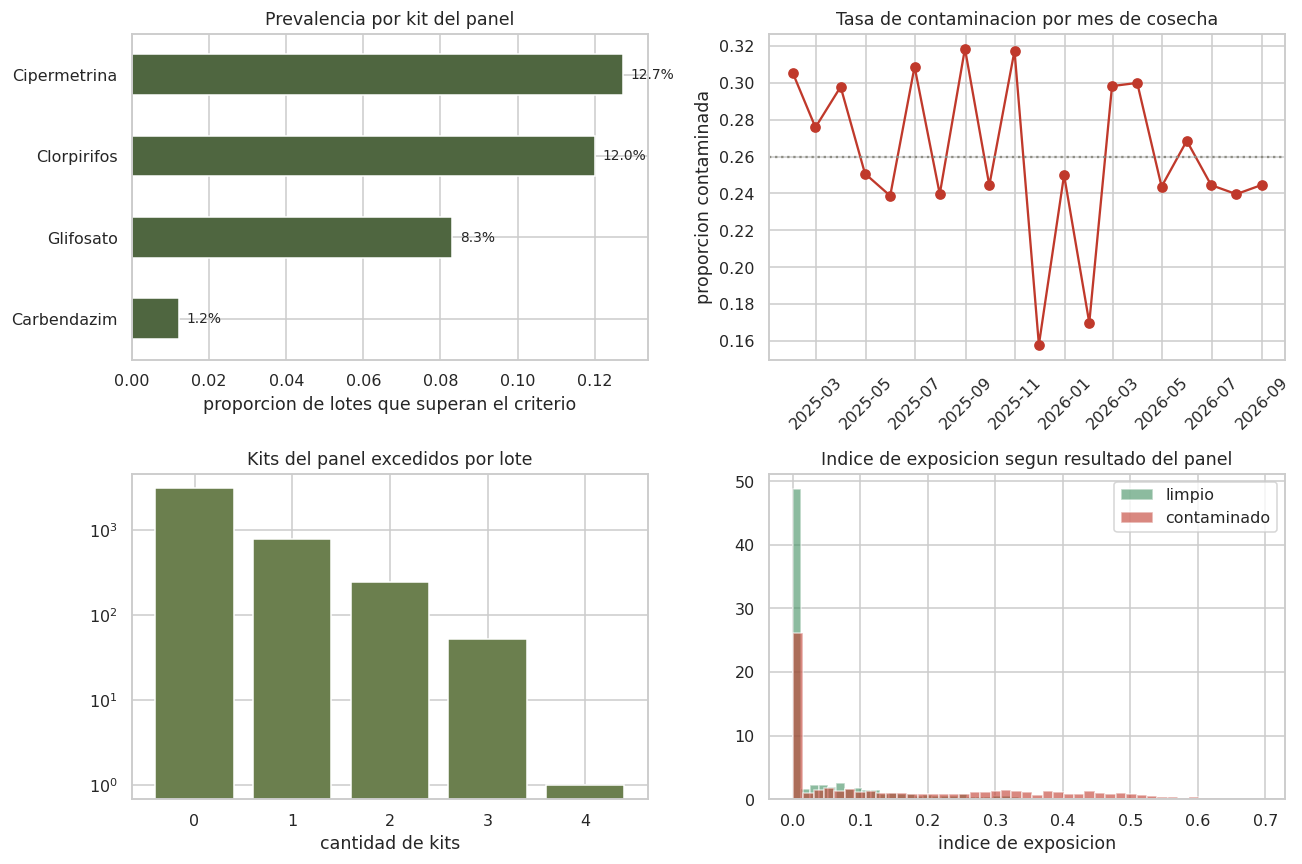

tasa global 25.95%
desviacion mensual de la tasa: 0.0441


In [4]:
fig, ejes = plt.subplots(2, 2, figsize=(12, 8))

# Prevalencia por kit del panel
kits = ["glifosato", "clorpirifos", "cipermetrina", "carbendazim"]
prev = pd.Series(
    {k.capitalize(): datos[f"excede_umbral_{k}"].mean() for k in kits}
).sort_values()
prev.plot.barh(ax=ejes[0, 0], color=PALETA[0])
ejes[0, 0].set_title("Prevalencia por kit del panel")
ejes[0, 0].set_xlabel("proporcion de lotes que superan el criterio")
for i, v in enumerate(prev.values):
    ejes[0, 0].text(v + 0.002, i, f"{v:.1%}", va="center", fontsize=9)

# Estabilidad temporal
serie = (
    datos.set_index("fecha_cosecha")["lote_contaminado"]
    .resample("ME").agg(["mean", "size"])
)
serie = serie[serie["size"] >= 25]
ejes[0, 1].plot(serie.index, serie["mean"], marker="o", color=PALETA[1])
ejes[0, 1].axhline(datos["lote_contaminado"].mean(), ls=":", color=PALETA[4])
ejes[0, 1].set_title("Tasa de contaminacion por mes de cosecha")
ejes[0, 1].set_ylabel("proporcion contaminada")
ejes[0, 1].tick_params(axis="x", rotation=45)

# Numero de kits excedidos
conteo = datos["n_kits_excedidos"].value_counts().sort_index()
ejes[1, 0].bar(conteo.index.astype(str), conteo.values, color=PALETA[3])
ejes[1, 0].set_title("Kits del panel excedidos por lote")
ejes[1, 0].set_xlabel("cantidad de kits")
ejes[1, 0].set_yscale("log")

# Separacion del indice de exposicion
for etiqueta, color, nombre in [(0, PALETA[5], "limpio"), (1, PALETA[1], "contaminado")]:
    sub = datos.loc[datos["lote_contaminado"] == etiqueta, "indice_exposicion"]
    ejes[1, 1].hist(sub, bins=45, alpha=0.6, color=color, label=nombre, density=True)
ejes[1, 1].set_title("Indice de exposicion segun resultado del panel")
ejes[1, 1].set_xlabel("indice de exposicion")
ejes[1, 1].legend()

plt.tight_layout()
plt.savefig(RESULTADOS / "eda" / "resumen_objetivo.png")
plt.show()

print(f"tasa global {datos['lote_contaminado'].mean():.2%}")
print(f"desviacion mensual de la tasa: {serie['mean'].std():.4f}")

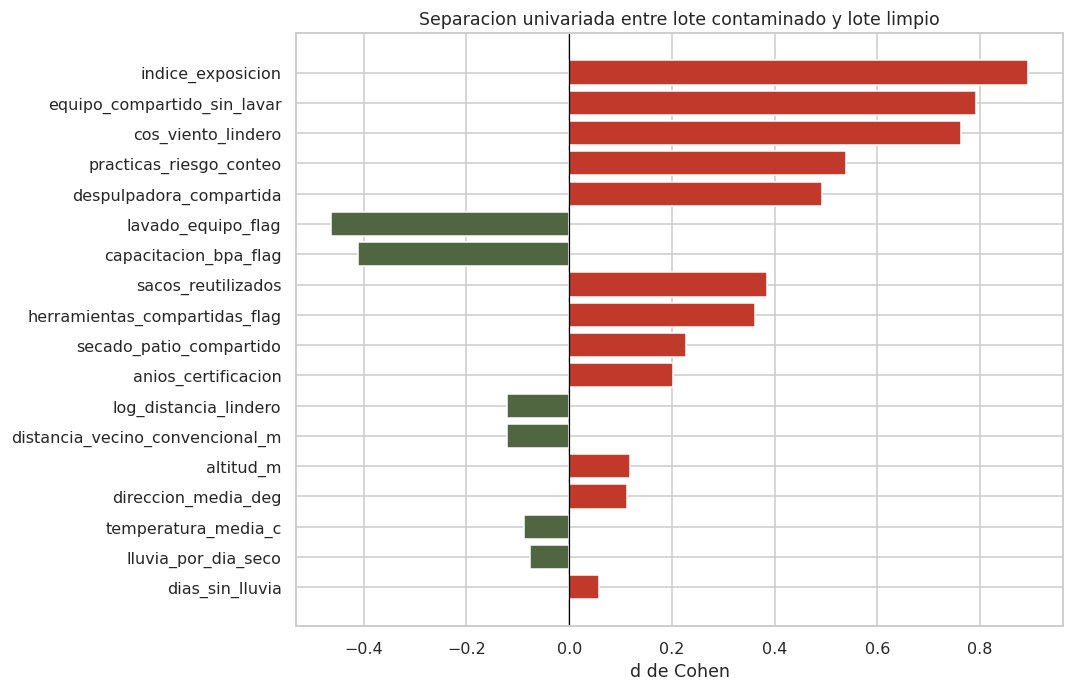

indice_exposicion                0.8940
equipo_compartido_sin_lavar      0.7925
cos_viento_lindero               0.7632
practicas_riesgo_conteo          0.5395
despulpadora_compartida          0.4920
lavado_equipo_flag              -0.4640
capacitacion_bpa_flag           -0.4120
sacos_reutilizados               0.3842
herramientas_compartidas_flag    0.3613
secado_patio_compartido          0.2274
anios_certificacion              0.2030
log_distancia_lindero           -0.1218


In [5]:
# Separacion univariada. Para cada variable numerica se compara la media
# del grupo contaminado contra la del grupo limpio, normalizada por la
# desviacion combinada. Es la d de Cohen, que permite ordenar variables de
# escalas distintas en una sola lista.
def d_de_cohen(serie, etiqueta):
    a = serie[etiqueta == 1]
    b = serie[etiqueta == 0]
    sd = np.sqrt(((len(a) - 1) * a.var() + (len(b) - 1) * b.var()) / (len(a) + len(b) - 2))
    return (a.mean() - b.mean()) / sd if sd > 0 else 0.0

FUGA = [
    "lote_id", "finca_id", "fecha_cosecha", "lat", "lon",
    "lote_contaminado", "n_kits_excedidos",
    "excede_umbral_glifosato", "excede_umbral_clorpirifos",
    "excede_umbral_cipermetrina", "excede_umbral_carbendazim",
]
CATEGORICAS = [
    "variedad", "destino_previsto", "tecnico_id",
    "vecino_fumigo_reciente", "empresa_exportadora",
]
NUMERICAS = [c for c in datos.columns if c not in FUGA + CATEGORICAS]

efectos = pd.Series(
    {c: d_de_cohen(datos[c], datos["lote_contaminado"]) for c in NUMERICAS}
).sort_values(key=abs, ascending=False)

fig, eje = plt.subplots(figsize=(9, 7))
top = efectos.head(18)[::-1]
eje.barh(top.index, top.values,
         color=[PALETA[1] if v > 0 else PALETA[0] for v in top.values])
eje.axvline(0, color="black", lw=0.8)
eje.set_title("Separacion univariada entre lote contaminado y lote limpio")
eje.set_xlabel("d de Cohen")
plt.savefig(RESULTADOS / "eda" / "separacion_univariada.png")
plt.show()

print(efectos.head(12).round(4).to_string())

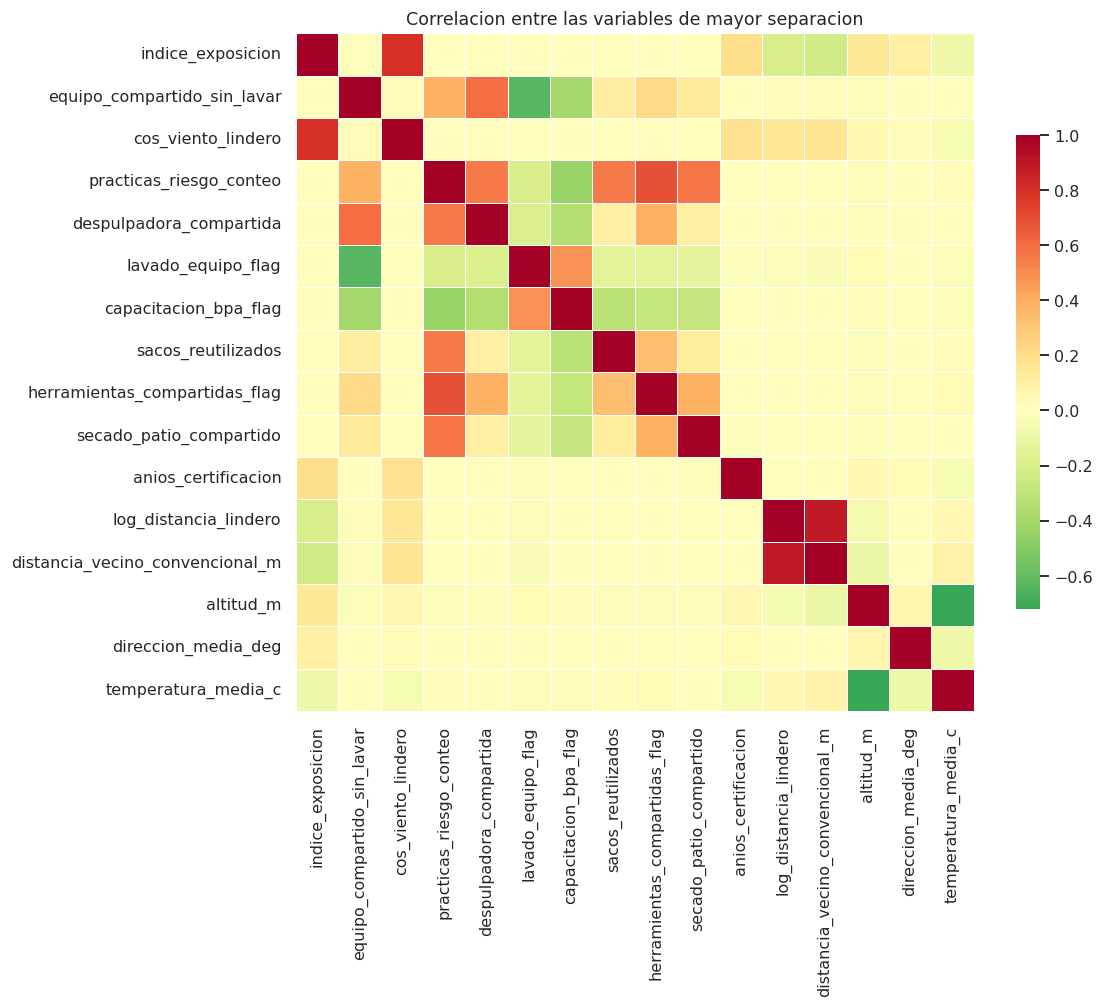

pares con correlacion absoluta sobre 0.80
log_distancia_lindero  distancia_vecino_convencional_m    0.884
indice_exposicion      cos_viento_lindero                 0.800


In [6]:
# Mapa de correlacion sobre las variables con mayor separacion. Interesa
# detectar pares redundantes antes de entrenar.
principales = list(efectos.head(16).index)
matriz = datos[principales].corr()

fig, eje = plt.subplots(figsize=(10, 8))
sns.heatmap(matriz, cmap="RdYlGn_r", center=0, annot=False,
            square=True, linewidths=0.4, cbar_kws={"shrink": 0.7}, ax=eje)
eje.set_title("Correlacion entre las variables de mayor separacion")
plt.savefig(RESULTADOS / "eda" / "correlacion.png")
plt.show()

alta = (
    matriz.where(np.triu(np.ones(matriz.shape), k=1).astype(bool))
    .stack()
    .pipe(lambda s: s[s.abs() > 0.80])
    .sort_values(key=abs, ascending=False)
)
print("pares con correlacion absoluta sobre 0.80")
print(alta.round(3).to_string() if len(alta) else "  ninguno")

## 4. Preparacion de variables

Tres transformaciones, cada una con un proposito distinto.

**Codificacion de categoricas con mapeo explicito.** Se guarda el
diccionario que va del valor original al entero en un archivo JSON. Sin
ese mapeo, el modelo entrenado es inservible en produccion: no habria
forma de saber que entero corresponde a que exportadora. El mapeo se
construye ordenando los valores alfabeticamente, de modo que sea
reproducible entre corridas.

**Escalado de numericas.** Los modelos de arboles no lo necesitan, pero se
deja calculado y guardado porque la regresion logistica que sirve de
referencia si lo requiere, y porque el escalador es parte del artefacto
que se despliega.

**Bucketizacion optima.** Cada variable numerica se discretiza buscando los
cortes que maximizan la separacion respecto del objetivo, con restriccion
de tamano minimo de bin. De ahi sale el valor de informacion, que es la
metrica con la que se refinan las variables en la tercera etapa.

In [7]:
from sklearn.preprocessing import StandardScaler

# Mapeo explicito. Se ordena para que la codificacion sea estable.
mapas_categorias = {}
for columna in CATEGORICAS:
    valores = sorted(datos[columna].astype(str).unique())
    mapas_categorias[columna] = {v: i for i, v in enumerate(valores)}
    datos[columna + "_enc"] = (
        datos[columna].astype(str).map(mapas_categorias[columna]).astype(int)
    )

ruta_mapas = RESULTADOS / "modelo" / "mapas_categorias.json"
ruta_mapas.write_text(
    json.dumps(mapas_categorias, indent=2, ensure_ascii=False), encoding="utf-8"
)

for columna, mapa in mapas_categorias.items():
    muestra = list(mapa.items())[:4]
    print(f"{columna:24s} {len(mapa):2d} niveles   {muestra}")
print(f"\nmapeo guardado en {ruta_mapas.relative_to(RAIZ)}")

variedad                  5 niveles   [('Bourbon', 0), ('Catimor', 1), ('Caturra', 2), ('Geisha', 3)]
destino_previsto          7 niveles   [('Alemania', 0), ('Belgica', 1), ('Estados_Unidos', 2), ('Francia', 3)]
tecnico_id               12 niveles   [('TEC01', 0), ('TEC02', 1), ('TEC03', 2), ('TEC04', 3)]
vecino_fumigo_reciente    3 niveles   [('No', 0), ('No_se_sabe', 1), ('Si', 2)]
empresa_exportadora       4 niveles   [('Cenfrocafe', 0), ('Coop. Norandino', 1), ('Olam Peru', 2), ('Perhusa', 3)]

mapeo guardado en resultados/modelo/mapas_categorias.json


In [8]:
CATEGORICAS_ENC = [c + "_enc" for c in CATEGORICAS]
VARIABLES = NUMERICAS + CATEGORICAS_ENC

escalador = StandardScaler().fit(datos[NUMERICAS])
resumen_escala = pd.DataFrame(
    {"media": escalador.mean_, "escala": escalador.scale_}, index=NUMERICAS
)
print(f"variables candidatas: {len(VARIABLES)}  "
      f"({len(NUMERICAS)} numericas, {len(CATEGORICAS_ENC)} categoricas)")
print()
print(resumen_escala.round(3).head(10).to_string())

variables candidatas: 38  (33 numericas, 5 categoricas)

                                 media  escala
peso_quintales                 143.114  66.926
dias_secado_patio               12.098   4.912
dias_desde_fumigacion_vecina     8.265  13.978
despulpadora_compartida          0.377   0.485
sacos_reutilizados               0.315   0.465
secado_patio_compartido          0.376   0.484
transporte_compartido            0.382   0.486
herramientas_compartidas_flag    0.805   0.396
lavado_equipo_flag               0.652   0.476
capacitacion_bpa_flag            0.540   0.498


## 5. Particion temporal

La particion es temporal y no aleatoria. Un lote comparte finca con otros
lotes de la misma campana, de modo que una particion aleatoria dejaria
lotes de la misma finca a ambos lados y el modelo aprenderia la finca en
vez del fenomeno. La particion temporal ademas reproduce la unica forma en
que el modelo se usa de verdad: entrenado con lo que ya paso, aplicado a
la cosecha que viene.

El conjunto intermedio cumple dos funciones: detener el entrenamiento por
parada temprana y ajustar tanto el umbral operativo como la calibracion
isotonica. Ninguna de esas tres decisiones puede tomarse sobre el conjunto
de prueba sin contaminar la estimacion.

In [9]:
entrena = datos[datos["fecha_cosecha"] < CORTE_CALIBRACION].copy()
calibra = datos[
    (datos["fecha_cosecha"] >= CORTE_CALIBRACION)
    & (datos["fecha_cosecha"] < CORTE_PRUEBA)
].copy()
prueba = datos[datos["fecha_cosecha"] >= CORTE_PRUEBA].copy()

OBJETIVO = "lote_contaminado"

for nombre, parte in [("entrenamiento", entrena), ("calibracion", calibra), ("prueba", prueba)]:
    print(f"{nombre:14s} {len(parte):>6,} lotes   "
          f"tasa {parte[OBJETIVO].mean():.2%}   "
          f"{parte['fecha_cosecha'].min().date()} a {parte['fecha_cosecha'].max().date()}")

print()
print(f"fincas compartidas entre entrenamiento y prueba: "
      f"{len(set(entrena.finca_id) & set(prueba.finca_id))}")
print("La particion es temporal, no por finca: en produccion se puntean "
      "lotes nuevos de fincas ya conocidas.")

entrenamiento   2,538 lotes   tasa 26.67%   2025-01-01 a 2026-03-31
calibracion     1,026 lotes   tasa 25.24%   2026-04-01 a 2026-06-30
prueba            636 lotes   tasa 24.21%   2026-07-01 a 2026-08-31

fincas compartidas entre entrenamiento y prueba: 103
La particion es temporal, no por finca: en produccion se puntean lotes nuevos de fincas ya conocidas.


In [10]:
import lightgbm as lgb
from sklearn.metrics import (
    average_precision_score, confusion_matrix, f1_score, precision_score,
    recall_score, roc_auc_score,
)

# Configuracion deliberadamente conservadora. Con dos mil quinientas filas
# de entrenamiento y una senal parcialmente estocastica por construccion,
# un modelo profundo memoriza la campana pasada y no generaliza.
PARAMETROS = dict(
    n_estimators=3000,
    learning_rate=0.015,
    max_depth=3,
    num_leaves=7,
    min_child_samples=80,
    subsample=0.8,
    subsample_freq=1,
    colsample_bytree=0.7,
    reg_lambda=10.0,
    random_state=SEMILLA,
    n_jobs=4,
    verbose=-1,
)


def elegir_umbral(y, p, recall_minimo=RECALL_MINIMO):
    """
    Umbral operativo. Se recorre la rejilla, se descartan los umbrales que
    no alcanzan el piso de recall y entre los que quedan se toma el de
    mayor F1. Si ninguno alcanza el piso, se devuelve el de mayor recall:
    la prioridad sigue siendo no dejar pasar un lote contaminado.
    """
    rejilla = np.linspace(0.02, 0.95, 187)
    filas = []
    for t in rejilla:
        yh = (p >= t).astype(int)
        filas.append((t, f1_score(y, yh, zero_division=0),
                      recall_score(y, yh, zero_division=0)))
    admisibles = [f for f in filas if f[2] >= recall_minimo]
    if admisibles:
        return max(admisibles, key=lambda f: f[1])[0]
    return max(filas, key=lambda f: f[2])[0]


historial = []


def entrenar_y_evaluar(columnas, etapa, guardar_modelo=True):
    """Entrena, elige umbral en calibracion y reporta sobre prueba."""
    modelo = lgb.LGBMClassifier(**PARAMETROS)
    modelo.fit(
        entrena[columnas], entrena[OBJETIVO],
        eval_set=[(calibra[columnas], calibra[OBJETIVO])],
        eval_metric="average_precision",
        callbacks=[lgb.early_stopping(150, verbose=False)],
    )

    p_cal = modelo.predict_proba(calibra[columnas])[:, 1]
    p_pru = modelo.predict_proba(prueba[columnas])[:, 1]
    umbral = elegir_umbral(calibra[OBJETIVO].values, p_cal)
    yh = (p_pru >= umbral).astype(int)
    y = prueba[OBJETIVO].values
    tn, fp, fn, tp = confusion_matrix(y, yh).ravel()

    fila = dict(
        etapa=etapa,
        variables=len(columnas),
        arboles=int(modelo.best_iteration_ or PARAMETROS["n_estimators"]),
        umbral=round(float(umbral), 3),
        f1=f1_score(y, yh),
        recall=recall_score(y, yh),
        precision=precision_score(y, yh),
        auc=roc_auc_score(y, p_pru),
        ap=average_precision_score(y, p_pru),
        falsos_negativos=int(fn),
        falsos_positivos=int(fp),
        recall_calibracion=recall_score(
            calibra[OBJETIVO].values, (p_cal >= umbral).astype(int)
        ),
    )
    historial.append(fila)

    print(f"{etapa:16s} variables={fila['variables']:3d} arboles={fila['arboles']:4d} "
          f"umbral={fila['umbral']:.3f}")
    print(f"{'':16s} F1={fila['f1']:.4f}  recall={fila['recall']:.4f}  "
          f"precision={fila['precision']:.4f}")
    print(f"{'':16s} AUC={fila['auc']:.4f}  AP={fila['ap']:.4f}  "
          f"falsos negativos={fila['falsos_negativos']}")
    return modelo, p_cal, p_pru

## 6. Primer entrenamiento. Filtrado por varianza y correlacion

Dos filtros estructurales que no miran el objetivo mas que para desempatar.

**Varianza nula.** Una columna constante no aporta informacion y solo
consume espacio en el arbol.

**Correlacion alta.** Cuando dos variables superan una correlacion absoluta
de 0.90 estan diciendo lo mismo. Se conserva la que tenga mayor
correlacion con el objetivo y se descarta la otra. La motivacion no es la
precision, que en arboles apenas cambia, sino la interpretabilidad: con
pares redundantes la importancia SHAP se reparte entre ambas y ninguna
aparece como relevante.

In [11]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.0).fit(entrena[VARIABLES])
sin_varianza = [c for c, ok in zip(VARIABLES, selector.get_support()) if not ok]

candidatas = [c for c in VARIABLES if c not in sin_varianza]

correlacion = entrena[candidatas].corr().abs()
con_objetivo = entrena[candidatas].corrwith(entrena[OBJETIVO]).abs()

descartadas_correlacion = set()
for i, a in enumerate(candidatas):
    if a in descartadas_correlacion:
        continue
    for b in candidatas[i + 1:]:
        if b in descartadas_correlacion:
            continue
        if correlacion.loc[a, b] > 0.90:
            perdedora = b if con_objetivo[a] >= con_objetivo[b] else a
            descartadas_correlacion.add(perdedora)

VARIABLES_E1 = [c for c in candidatas if c not in descartadas_correlacion]

print(f"sin varianza          {len(sin_varianza):3d}  {sin_varianza}")
print(f"correlacion sobre 0.90 {len(descartadas_correlacion):3d}  "
      f"{sorted(descartadas_correlacion)}")
print(f"sobreviven            {len(VARIABLES_E1):3d} de {len(VARIABLES)}")
print()
modelo_e1, pcal_e1, ppru_e1 = entrenar_y_evaluar(VARIABLES_E1, "first train")

sin varianza            0  []
correlacion sobre 0.90   0  []
sobreviven             38 de 38



first train      variables= 38 arboles= 139 umbral=0.230
                 F1=0.5833  recall=0.8182  precision=0.4532
                 AUC=0.8353  AP=0.6718  falsos negativos=28


## 7. Segundo entrenamiento. Filtrado por valores SHAP

La importancia por ganancia que reporta el arbol favorece a las variables
de alta cardinalidad y depende del orden en que se hicieron los cortes.
Los valores SHAP reparten la prediccion entre las variables de forma
aditiva y consistente, y se calculan sobre el conjunto de calibracion y no
sobre el de entrenamiento, para que la importancia refleje capacidad de
generalizacion y no memorizacion.

Se ordenan las variables por la media del valor absoluto de su
contribucion y se retiene el conjunto minimo que acumula el noventa y
cinco por ciento de la importancia total. La cola restante son variables
cuyo aporte medio a la prediccion es indistinguible de cero.

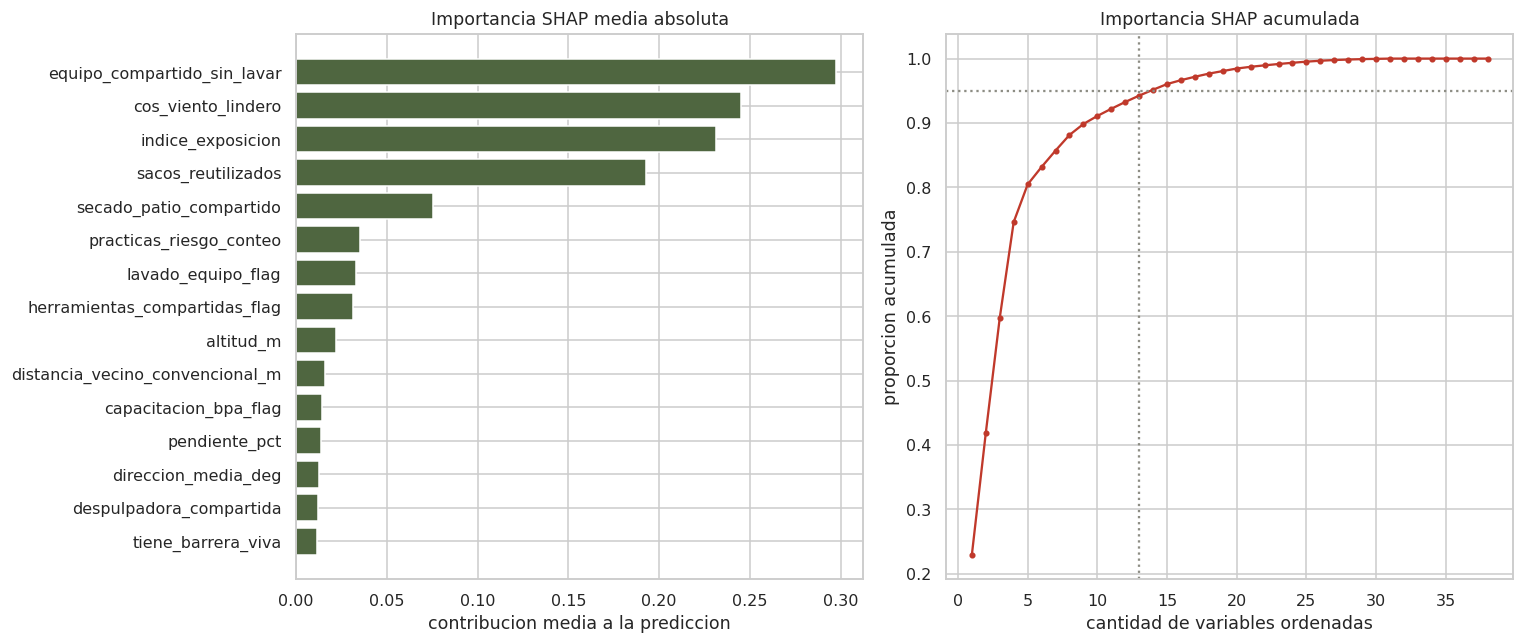

retenidas 13 de 38

equipo_compartido_sin_lavar        0.29750
cos_viento_lindero                 0.24509
indice_exposicion                  0.23108
sacos_reutilizados                 0.19268
secado_patio_compartido            0.07553
practicas_riesgo_conteo            0.03520
lavado_equipo_flag                 0.03291
herramientas_compartidas_flag      0.03138
altitud_m                          0.02211
distancia_vecino_convencional_m    0.01616
capacitacion_bpa_flag              0.01444
pendiente_pct                      0.01367



second train     variables= 13 arboles= 144 umbral=0.230
                 F1=0.5659  recall=0.7662  precision=0.4487
                 AUC=0.8324  AP=0.6678  falsos negativos=36


In [12]:
import shap

explicador = shap.TreeExplainer(modelo_e1)
valores_shap = explicador.shap_values(calibra[VARIABLES_E1])

# La forma del arreglo depende de la version de la biblioteca y del tipo de
# objetivo. Se normaliza a una matriz de observaciones por variables.
if isinstance(valores_shap, list):
    valores_shap = valores_shap[1]
if valores_shap.ndim == 3:
    valores_shap = valores_shap[:, :, 1]

importancia_shap = (
    pd.Series(np.abs(valores_shap).mean(axis=0), index=VARIABLES_E1)
    .sort_values(ascending=False)
)

acumulada = importancia_shap.cumsum() / importancia_shap.sum()
VARIABLES_E2 = list(acumulada[acumulada <= COBERTURA_SHAP].index)
if importancia_shap.index[0] not in VARIABLES_E2:
    VARIABLES_E2 = [importancia_shap.index[0]] + VARIABLES_E2

fig, ejes = plt.subplots(1, 2, figsize=(14, 6))

top = importancia_shap.head(15)[::-1]
ejes[0].barh(top.index, top.values, color=PALETA[0])
ejes[0].set_title("Importancia SHAP media absoluta")
ejes[0].set_xlabel("contribucion media a la prediccion")

ejes[1].plot(range(1, len(acumulada) + 1), acumulada.values,
             marker="o", ms=3, color=PALETA[1])
ejes[1].axhline(COBERTURA_SHAP, ls=":", color=PALETA[4])
ejes[1].axvline(len(VARIABLES_E2), ls=":", color=PALETA[4])
ejes[1].set_title("Importancia SHAP acumulada")
ejes[1].set_xlabel("cantidad de variables ordenadas")
ejes[1].set_ylabel("proporcion acumulada")

plt.tight_layout()
plt.savefig(RESULTADOS / "modelo" / "importancia_shap.png")
plt.show()

print(f"retenidas {len(VARIABLES_E2)} de {len(VARIABLES_E1)}")
print()
print(importancia_shap.head(12).round(5).to_string())
print()
modelo_e2, pcal_e2, ppru_e2 = entrenar_y_evaluar(VARIABLES_E2, "second train")

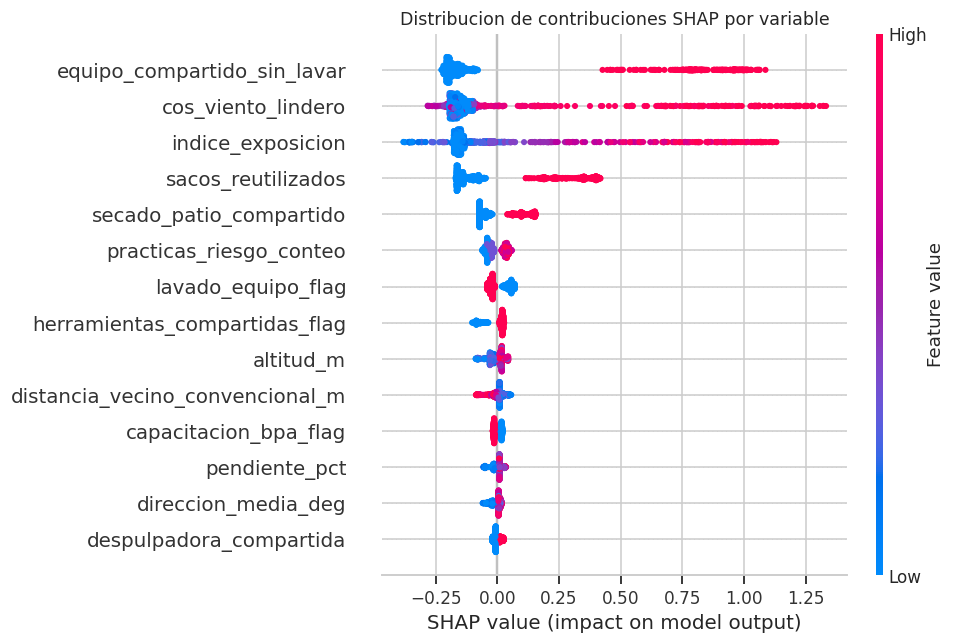

In [13]:
# Grafico de dispersion SHAP. Muestra no solo cuanto pesa cada variable
# sino en que direccion: si valores altos empujan hacia contaminado.
plt.figure(figsize=(9, 6))
shap.summary_plot(
    valores_shap, calibra[VARIABLES_E1], max_display=14, show=False, plot_size=None
)
plt.title("Distribucion de contribuciones SHAP por variable")
plt.tight_layout()
plt.savefig(RESULTADOS / "modelo" / "shap_dispersion.png")
plt.show()

## 8. Tercer entrenamiento. Refinamiento numerico y categorico

La ultima etapa trata numericas y categoricas con criterios distintos,
porque el riesgo que corre cada grupo es distinto.

**Numericas.** Se bucketizan de forma optima contra el objetivo y se
calcula su valor de informacion. Se conservan las que superan el umbral
acordado. El valor de informacion detecta separacion no lineal que la
correlacion no ve, y penaliza a las variables cuya aparente importancia
proviene de unos pocos puntos extremos.

**Categoricas.** Aqui la metrica no decide sola. Se cruza el valor de
informacion con un criterio de negocio y bioingenieria que responde a una
pregunta previa: existe un mecanismo fisico por el que esta variable pueda
causar la presencia de residuo en el grano. Una variable puede separar bien
y aun asi no deber entrar, porque lo que esta capturando es un atajo que se
rompera en cuanto cambie la operacion.

In [14]:
from optbinning import OptimalBinning

def valor_de_informacion(columna, tipo):
    """Valor de informacion a partir de la bucketizacion optima."""
    try:
        binner = OptimalBinning(
            name=columna, dtype=tipo, solver="cp" if tipo == "numerical" else "mip",
            max_n_bins=5, min_bin_size=0.05,
        )
        if tipo == "numerical":
            binner.fit(entrena[columna].values, entrena[OBJETIVO].values)
        else:
            binner.fit(entrena[columna].astype(str).values, entrena[OBJETIVO].values)
        return float(binner.binning_table.build().iloc[-1]["IV"]), binner
    except Exception:
        return 0.0, None


numericas_e2 = [c for c in VARIABLES_E2 if not c.endswith("_enc")]

iv_numericas, binners = {}, {}
for columna in numericas_e2:
    iv, binner = valor_de_informacion(columna, "numerical")
    iv_numericas[columna] = iv
    if binner is not None:
        binners[columna] = binner

iv_numericas = pd.Series(iv_numericas).sort_values(ascending=False)
NUMERICAS_E3 = list(iv_numericas[iv_numericas >= IV_MINIMO].index)

print("valor de informacion de las numericas")
print(iv_numericas.round(4).to_string())
print()
print(f"conservadas {len(NUMERICAS_E3)} de {len(numericas_e2)} "
      f"con valor de informacion sobre {IV_MINIMO}")

valor de informacion de las numericas
indice_exposicion                  0.6916
cos_viento_lindero                 0.6423
equipo_compartido_sin_lavar        0.3922
practicas_riesgo_conteo            0.2478
lavado_equipo_flag                 0.1632
capacitacion_bpa_flag              0.1499
herramientas_compartidas_flag      0.1346
sacos_reutilizados                 0.1262
altitud_m                          0.1066
direccion_media_deg                0.0831
distancia_vecino_convencional_m    0.0802
pendiente_pct                      0.0700
secado_patio_compartido            0.0593

conservadas 13 de 13 con valor de informacion sobre 0.02


In [15]:
# Criterio de negocio y bioingenieria sobre las categoricas. Se evalua
# sobre TODAS, no solo sobre las que sobrevivieron a SHAP, porque una
# variable con mecanismo causal claro merece una segunda revision aunque la
# importancia la haya descartado.
CRITERIO_NEGOCIO = {
    "vecino_fumigo_reciente": (
        True,
        "declara la aplicacion en el lindero, que es la entrada directa del "
        "modelo de deriva",
    ),
    "empresa_exportadora": (
        False,
        "agrupa comercialmente pero no interviene en el mecanismo fisico de "
        "contaminacion del grano",
    ),
    "variedad": (
        False,
        "no altera la captacion de residuo en el pergamino de forma "
        "documentada",
    ),
    "destino_previsto": (
        False,
        "se asigna despues de la cosecha, no puede ser causa de un residuo "
        "que ya estaba",
    ),
    "tecnico_id": (
        False,
        "identificador de operador: el modelo aprenderia quien reporta y no "
        "que ocurre, y se rompe al rotar personal",
    ),
}

iv_categoricas = pd.Series(
    {c: valor_de_informacion(c, "categorical")[0] for c in CATEGORICAS}
).sort_values(ascending=False)

print("decision por variable categorica")
print()
CATEGORICAS_E3 = []
for columna in iv_categoricas.index:
    admite_negocio, motivo = CRITERIO_NEGOCIO[columna]
    admite_metrica = iv_categoricas[columna] >= IV_MINIMO
    entra = admite_negocio and admite_metrica

    if entra:
        CATEGORICAS_E3.append(columna + "_enc")
        veredicto = "ENTRA"
    elif admite_negocio and not admite_metrica:
        veredicto = "fuera por metrica"
    elif admite_metrica and not admite_negocio:
        veredicto = "VETADA por criterio de negocio"
    else:
        veredicto = "fuera por ambos"

    print(f"  {columna:24s} IV={iv_categoricas[columna]:.4f}  {veredicto}")
    print(f"  {'':24s} {motivo}")
    print()

VARIABLES_E3 = NUMERICAS_E3 + CATEGORICAS_E3
print(f"conjunto final: {len(VARIABLES_E3)} variables "
      f"({len(NUMERICAS_E3)} numericas, {len(CATEGORICAS_E3)} categoricas)")
print()
modelo_e3, pcal_e3, ppru_e3 = entrenar_y_evaluar(VARIABLES_E3, "third train")

decision por variable categorica

  tecnico_id               IV=0.0284  VETADA por criterio de negocio
                           identificador de operador: el modelo aprenderia quien reporta y no que ocurre, y se rompe al rotar personal

  empresa_exportadora      IV=0.0133  fuera por ambos
                           agrupa comercialmente pero no interviene en el mecanismo fisico de contaminacion del grano

  destino_previsto         IV=0.0052  fuera por ambos
                           se asigna despues de la cosecha, no puede ser causa de un residuo que ya estaba

  variedad                 IV=0.0037  fuera por ambos
                           no altera la captacion de residuo en el pergamino de forma documentada

  vecino_fumigo_reciente   IV=0.0017  fuera por metrica
                           declara la aplicacion en el lindero, que es la entrada directa del modelo de deriva

conjunto final: 13 variables (13 numericas, 0 categoricas)



third train      variables= 13 arboles=  21 umbral=0.260
                 F1=0.5803  recall=0.7857  precision=0.4601
                 AUC=0.8313  AP=0.6679  falsos negativos=33


comparativa de las tres etapas sobre el conjunto de prueba

              variables  arboles  umbral      f1  recall  precision     auc      ap  falsos_negativos  falsos_positivos  recall_calibracion
etapa                                                                                                                                      
first train          38      139    0.23  0.5833  0.8182     0.4532  0.8353  0.6718                28               152              0.8031
second train         13      144    0.23  0.5659  0.7662     0.4487  0.8324  0.6678                36               145              0.8108
third train          13       21    0.26  0.5803  0.7857     0.4601  0.8313  0.6679                33               142              0.8108


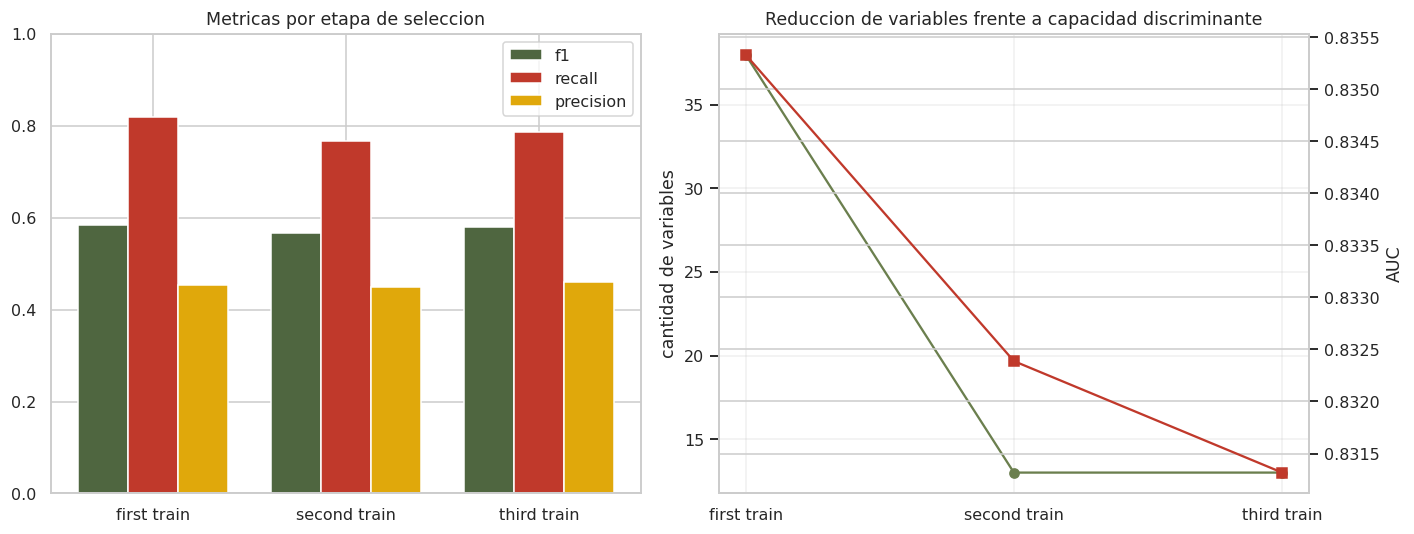

In [16]:
comparativa = pd.DataFrame(historial).set_index("etapa")
print("comparativa de las tres etapas sobre el conjunto de prueba")
print()
print(comparativa.round(4).to_string())

fig, ejes = plt.subplots(1, 2, figsize=(13, 5))

x = np.arange(len(comparativa))
ancho = 0.26
for i, (metrica, color) in enumerate(
    [("f1", PALETA[0]), ("recall", PALETA[1]), ("precision", PALETA[2])]
):
    ejes[0].bar(x + (i - 1) * ancho, comparativa[metrica], ancho,
                label=metrica, color=color)
ejes[0].set_xticks(x)
ejes[0].set_xticklabels(comparativa.index)
ejes[0].set_title("Metricas por etapa de seleccion")
ejes[0].legend()
ejes[0].set_ylim(0, 1)

ejes[1].plot(comparativa.index, comparativa["variables"], marker="o",
             color=PALETA[3], label="variables")
ejes[1].set_ylabel("cantidad de variables")
gemelo = ejes[1].twinx()
gemelo.plot(comparativa.index, comparativa["auc"], marker="s",
            color=PALETA[1], label="AUC")
gemelo.set_ylabel("AUC")
ejes[1].set_title("Reduccion de variables frente a capacidad discriminante")
ejes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTADOS / "modelo" / "comparativa_etapas.png")
plt.show()

VARIABLES_FINALES = VARIABLES_E3
modelo_final = modelo_e3

## 9. Umbral operativo y calibracion isotonica

El modelo entrega un puntaje que ordena bien, pero ese puntaje no es una
probabilidad: si el modelo dice 0.30, no significa que treinta de cada cien
lotes con ese puntaje esten contaminados. Para la alerta del tablero basta
con el orden, pero el modelo de optimizacion necesita probabilidades de
verdad, porque su restriccion de riesgo del contenedor se expresa como una
probabilidad promedio y compara contra una tolerancia contractual.

La regresion isotonica ajusta una funcion monotona por tramos que lleva el
puntaje a la frecuencia observada. Es monotona por construccion, asi que
preserva el ordenamiento y no puede degradar la capacidad discriminante:
AUC no cambia. Se ajusta sobre el conjunto de calibracion, nunca sobre el
de prueba.

         sin calibrar  calibrada
Brier          0.1643     0.1308
LogLoss        0.5062     0.4281
AUC            0.8313     0.8270


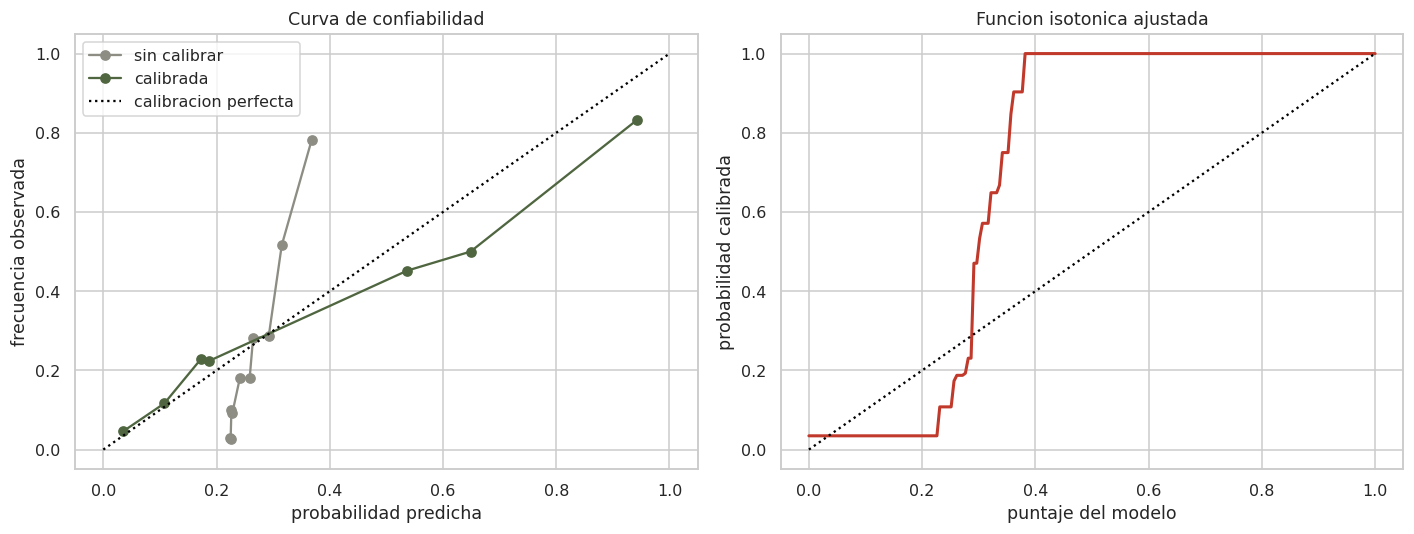

In [17]:
from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import brier_score_loss, log_loss

isotonica = IsotonicRegression(out_of_bounds="clip", y_min=0.0, y_max=1.0)
isotonica.fit(pcal_e3, calibra[OBJETIVO].values)

p_prueba_cruda = ppru_e3
p_prueba_calibrada = isotonica.predict(p_prueba_cruda)
y_prueba = prueba[OBJETIVO].values

recorte = lambda p: np.clip(p, 1e-6, 1 - 1e-6)
metricas_calibracion = pd.DataFrame(
    {
        "sin calibrar": [
            brier_score_loss(y_prueba, p_prueba_cruda),
            log_loss(y_prueba, recorte(p_prueba_cruda)),
            roc_auc_score(y_prueba, p_prueba_cruda),
        ],
        "calibrada": [
            brier_score_loss(y_prueba, p_prueba_calibrada),
            log_loss(y_prueba, recorte(p_prueba_calibrada)),
            roc_auc_score(y_prueba, p_prueba_calibrada),
        ],
    },
    index=["Brier", "LogLoss", "AUC"],
)
print(metricas_calibracion.round(4).to_string())

fig, ejes = plt.subplots(1, 2, figsize=(13, 5))

for p, nombre, color in [
    (p_prueba_cruda, "sin calibrar", PALETA[4]),
    (p_prueba_calibrada, "calibrada", PALETA[0]),
]:
    obs, pred = calibration_curve(y_prueba, p, n_bins=10, strategy="quantile")
    ejes[0].plot(pred, obs, marker="o", label=nombre, color=color)
ejes[0].plot([0, 1], [0, 1], ls=":", color="black", label="calibracion perfecta")
ejes[0].set_xlabel("probabilidad predicha")
ejes[0].set_ylabel("frecuencia observada")
ejes[0].set_title("Curva de confiabilidad")
ejes[0].legend()

rejilla = np.linspace(0, 1, 200)
ejes[1].plot(rejilla, isotonica.predict(rejilla), color=PALETA[1], lw=2)
ejes[1].plot([0, 1], [0, 1], ls=":", color="black")
ejes[1].set_xlabel("puntaje del modelo")
ejes[1].set_ylabel("probabilidad calibrada")
ejes[1].set_title("Funcion isotonica ajustada")

plt.tight_layout()
plt.savefig(RESULTADOS / "modelo" / "calibracion.png")
plt.show()

umbral operativo con piso de recall 80%: 0.175

  F1        0.5681
  recall    0.7987
  precision 0.4409

matriz de confusion sobre el conjunto de prueba
  verdaderos negativos  326    falsos positivos  156
  falsos negativos       31    verdaderos positivos  123

  lotes contaminados que se escapan: 31 de 154 (20.1%)
  lotes limpios enviados a revision: 156 de 482 (32.4%)


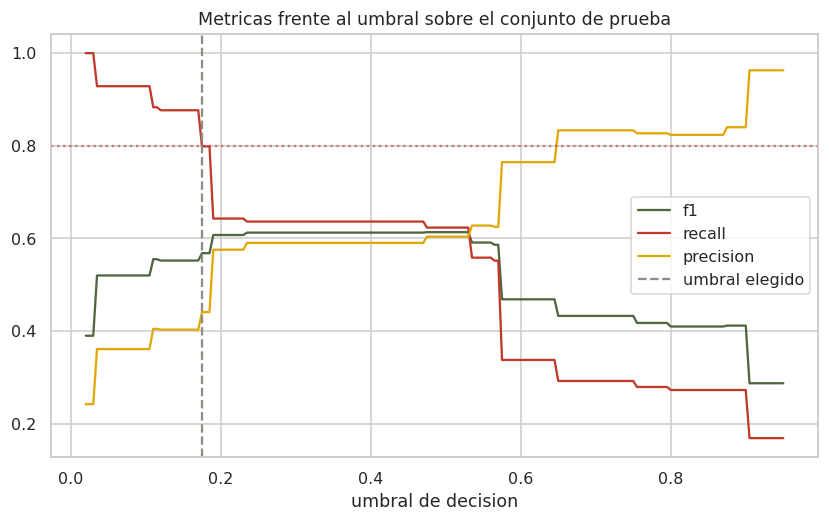

In [18]:
# Umbral operativo sobre la escala ya calibrada.
pcal_calibrada = isotonica.predict(pcal_e3)
UMBRAL_OPERATIVO = elegir_umbral(calibra[OBJETIVO].values, pcal_calibrada)

y_pred = (p_prueba_calibrada >= UMBRAL_OPERATIVO).astype(int)
tn, fp, fn, tp = confusion_matrix(y_prueba, y_pred).ravel()

print(f"umbral operativo con piso de recall {RECALL_MINIMO:.0%}: {UMBRAL_OPERATIVO:.3f}")
print()
print(f"  F1        {f1_score(y_prueba, y_pred):.4f}")
print(f"  recall    {recall_score(y_prueba, y_pred):.4f}")
print(f"  precision {precision_score(y_prueba, y_pred):.4f}")
print()
print("matriz de confusion sobre el conjunto de prueba")
print(f"  verdaderos negativos {tn:4d}    falsos positivos {fp:4d}")
print(f"  falsos negativos     {fn:4d}    verdaderos positivos {tp:4d}")
print()
print(f"  lotes contaminados que se escapan: {fn} de {tp + fn} "
      f"({fn / max(tp + fn, 1):.1%})")
print(f"  lotes limpios enviados a revision: {fp} de {tn + fp} "
      f"({fp / max(tn + fp, 1):.1%})")

# Frontera de decision: como se mueven las metricas con el umbral.
rejilla = np.linspace(0.02, 0.95, 187)
curva = pd.DataFrame(
    [
        {
            "umbral": t,
            "f1": f1_score(y_prueba, (p_prueba_calibrada >= t).astype(int),
                           zero_division=0),
            "recall": recall_score(y_prueba, (p_prueba_calibrada >= t).astype(int),
                                   zero_division=0),
            "precision": precision_score(y_prueba, (p_prueba_calibrada >= t).astype(int),
                                         zero_division=0),
        }
        for t in rejilla
    ]
)

fig, eje = plt.subplots(figsize=(9, 5))
for metrica, color in [("f1", PALETA[0]), ("recall", PALETA[1]), ("precision", PALETA[2])]:
    eje.plot(curva["umbral"], curva[metrica], label=metrica, color=color)
eje.axvline(UMBRAL_OPERATIVO, ls="--", color=PALETA[4], label="umbral elegido")
eje.axhline(RECALL_MINIMO, ls=":", color=PALETA[1], alpha=0.6)
eje.set_xlabel("umbral de decision")
eje.set_title("Metricas frente al umbral sobre el conjunto de prueba")
eje.legend()
plt.savefig(RESULTADOS / "modelo" / "frontera_umbral.png")
plt.show()

## 10. Validacion por deciles

La curva de confiabilidad dice si las probabilidades estan bien
calibradas en promedio. El analisis por deciles responde una pregunta
distinta y mas operativa: si la cooperativa solo puede correr el panel
completo sobre una parte de los lotes, cuanto de la contaminacion real
captura si prioriza por puntaje.

Se ordenan los lotes de prueba de mayor a menor probabilidad y se parten en
diez grupos iguales. Un modelo que discrimina y ordena bien cumple tres
cosas: la tasa observada cae de forma monotona del decil uno al diez, el
primer decil tiene un lift muy por encima de uno, y la captura acumulada
sube rapido en los primeros deciles.

In [19]:
deciles = pd.DataFrame({"p": p_prueba_calibrada, "y": y_prueba})
deciles["decil"] = pd.qcut(
    deciles["p"].rank(method="first"), 10, labels=range(10, 0, -1)
).astype(int)

tabla = (
    deciles.groupby("decil")
    .agg(lotes=("y", "size"), contaminados=("y", "sum"),
         tasa_observada=("y", "mean"), prob_media=("p", "mean"))
    .sort_index()
)
tabla["lift"] = tabla["tasa_observada"] / deciles["y"].mean()
tabla["captura_acumulada"] = tabla["contaminados"].cumsum() / tabla["contaminados"].sum()
tabla["volumen_acumulado"] = tabla["lotes"].cumsum() / tabla["lotes"].sum()

print(tabla.round(4).to_string())

diferencias = tabla["tasa_observada"].diff().dropna()
monotona = bool((diferencias <= 1e-9).all())
inversiones = int((diferencias > 1e-9).sum())

from scipy.stats import ks_2samp
ks = ks_2samp(
    p_prueba_calibrada[y_prueba == 1], p_prueba_calibrada[y_prueba == 0]
).statistic

print()
print(f"monotonia estricta entre deciles: {monotona}")
print(f"inversiones observadas: {inversiones}")
print(f"lift del primer decil: {tabla.loc[1, 'lift']:.2f}")
print(f"captura en los tres primeros deciles: {tabla.loc[3, 'captura_acumulada']:.1%}")
print(f"estadistico de Kolmogorov Smirnov: {ks:.4f}")

       lotes  contaminados  tasa_observada  prob_media    lift  captura_acumulada  volumen_acumulado
decil                                                                                               
1         64            50          0.7812      0.8974  3.2265             0.3247             0.1006
2         63            31          0.4921      0.5763  2.0322             0.5260             0.1997
3         64            23          0.3594      0.4013  1.4842             0.6753             0.3003
4         63            12          0.1905      0.1875  0.7866             0.7532             0.3994
5         64            15          0.2344      0.1787  0.9679             0.8506             0.5000
6         63             9          0.1429      0.1256  0.5900             0.9091             0.5991
7         64             6          0.0938      0.0519  0.3872             0.9481             0.6997
8         63             4          0.0635      0.0348  0.2622             0.9740          

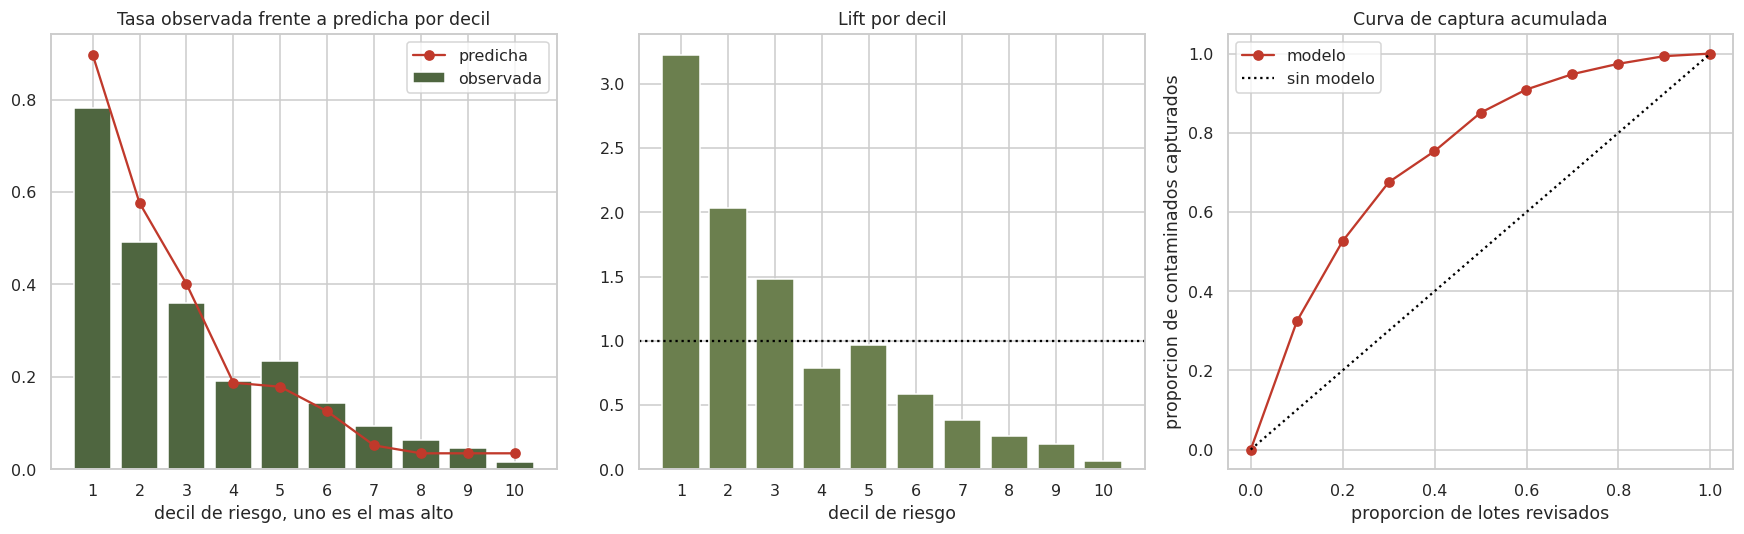

In [20]:
fig, ejes = plt.subplots(1, 3, figsize=(16, 5))

ejes[0].bar(tabla.index.astype(str), tabla["tasa_observada"],
            color=PALETA[0], label="observada")
ejes[0].plot(tabla.index.astype(str), tabla["prob_media"], marker="o",
             color=PALETA[1], label="predicha")
ejes[0].set_title("Tasa observada frente a predicha por decil")
ejes[0].set_xlabel("decil de riesgo, uno es el mas alto")
ejes[0].legend()

ejes[1].bar(tabla.index.astype(str), tabla["lift"], color=PALETA[3])
ejes[1].axhline(1.0, ls=":", color="black")
ejes[1].set_title("Lift por decil")
ejes[1].set_xlabel("decil de riesgo")

ejes[2].plot([0] + list(tabla["volumen_acumulado"]),
             [0] + list(tabla["captura_acumulada"]),
             marker="o", color=PALETA[1], label="modelo")
ejes[2].plot([0, 1], [0, 1], ls=":", color="black", label="sin modelo")
ejes[2].set_xlabel("proporcion de lotes revisados")
ejes[2].set_ylabel("proporcion de contaminados capturados")
ejes[2].set_title("Curva de captura acumulada")
ejes[2].legend()

plt.tight_layout()
plt.savefig(RESULTADOS / "modelo" / "analisis_deciles.png")
plt.show()

tabla.to_csv(RESULTADOS / "modelo" / "analisis_deciles.csv")

## 11. Modelo multietiqueta por agroquimico

El modelo anterior responde si el lote esta contaminado. Este responde por
cual de los cuatro kits, que es una pregunta distinta y con valor propio:
si el sistema puede anticipar que el riesgo viene del herbicida y no del
fungicida, la cooperativa corre primero ese kit y ahorra los otros tres.

Se envuelve un clasificador por etiqueta y se reportan las metricas por
separado, porque las prevalencias son muy distintas entre kits y una
metrica agregada las escondería.

              prevalencia  umbral      f1  recall  precision     auc
agroquimico                                                         
Glifosato          0.0802   0.315  0.6939  0.6667     0.7234  0.9270
Clorpirifos        0.0928   0.345  0.3654  0.3220     0.4222  0.7608
Cipermetrina       0.1179   0.170  0.3333  0.5200     0.2453  0.7713
Carbendazim        0.0173   0.075  0.5000  0.3636     0.8000  0.9305

El valor de este modelo esta en el ordenamiento, que mide AUC, no en la clasificacion dura. Con AUC sobre 0.90 en glifosato y carbendazim,
la cooperativa puede correr primero esos dos kits y dejar los otros dos para los lotes que sigan en duda.


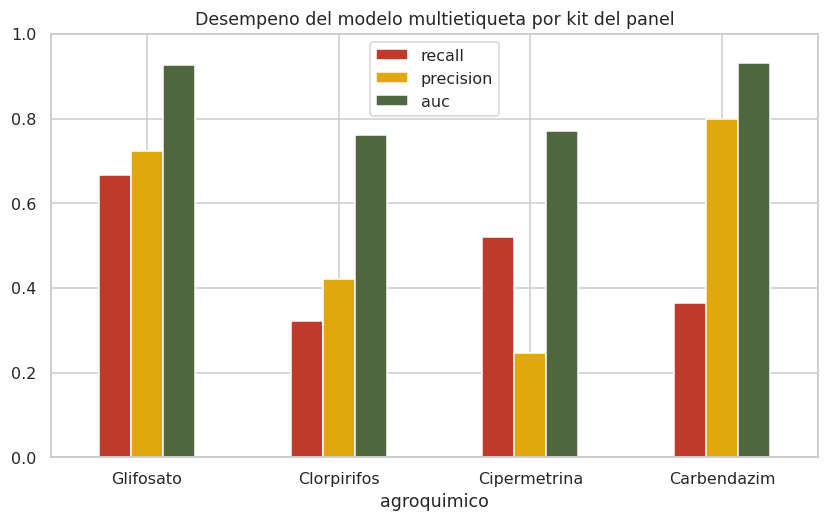

In [21]:
from sklearn.multioutput import MultiOutputClassifier

ETIQUETAS = [
    "excede_umbral_glifosato", "excede_umbral_clorpirifos",
    "excede_umbral_cipermetrina", "excede_umbral_carbendazim",
]

parametros_multi = dict(PARAMETROS)
parametros_multi.update(n_estimators=400, learning_rate=0.03, n_jobs=2)

multietiqueta = MultiOutputClassifier(lgb.LGBMClassifier(**parametros_multi))
multietiqueta.fit(entrena[VARIABLES_FINALES], entrena[ETIQUETAS])

probas = np.column_stack(
    [e[:, 1] for e in multietiqueta.predict_proba(prueba[VARIABLES_FINALES])]
)
probas_calibracion = np.column_stack(
    [e[:, 1] for e in multietiqueta.predict_proba(calibra[VARIABLES_FINALES])]
)

filas = []
for i, etiqueta in enumerate(ETIQUETAS):
    y = prueba[etiqueta].values
    p = probas[:, i]
    # Sin piso de recall a proposito. Este modelo no decide si un lote pasa
    # o no: ordena que kit conviene correr primero. Para esa tarea manda la
    # calidad del ordenamiento, y forzar el piso de recall aqui hundiria la
    # precision sin mejorar la decision que realmente se toma.
    umbral = elegir_umbral(
        calibra[etiqueta].values, probas_calibracion[:, i], recall_minimo=0.0
    )
    yh = (p >= umbral).astype(int)
    filas.append({
        "agroquimico": etiqueta.replace("excede_umbral_", "").capitalize(),
        "prevalencia": y.mean(),
        "umbral": round(float(umbral), 3),
        "f1": f1_score(y, yh, zero_division=0),
        "recall": recall_score(y, yh, zero_division=0),
        "precision": precision_score(y, yh, zero_division=0),
        "auc": roc_auc_score(y, p) if y.sum() else np.nan,
    })

resumen_multi = pd.DataFrame(filas).set_index("agroquimico")
print(resumen_multi.round(4).to_string())
print()
print("El valor de este modelo esta en el ordenamiento, que mide AUC, no en "
      "la clasificacion dura. Con AUC sobre 0.90 en glifosato y carbendazim,")
print("la cooperativa puede correr primero esos dos kits y dejar los otros "
      "dos para los lotes que sigan en duda.")
resumen_multi.to_csv(RESULTADOS / "modelo" / "metricas_multietiqueta.csv")

fig, eje = plt.subplots(figsize=(9, 5))
resumen_multi[["recall", "precision", "auc"]].plot.bar(
    ax=eje, color=[PALETA[1], PALETA[2], PALETA[0]]
)
eje.set_title("Desempeno del modelo multietiqueta por kit del panel")
eje.set_ylim(0, 1)
eje.tick_params(axis="x", rotation=0)
plt.savefig(RESULTADOS / "modelo" / "multietiqueta.png")
plt.show()

## 12. Modelo de optimizacion entera mixta

Con las probabilidades calibradas ya se puede decidir. La pregunta que
resuelve el optimizador es: que subconjunto de lotes se manda a exportacion
organica de modo que se maximice el valor y no se rompa el compromiso de
riesgo con el comprador.

**Variable de decision.** Una binaria por lote. Vale uno si el lote va a
exportacion organica y cero si se segrega a mercado convencional.

**Funcion objetivo.** Se maximiza el ingreso total menos una penalizacion
proporcional al riesgo que se introduce en el contenedor. El ingreso de un
lote segregado no es cero: se vende igual, a menor precio. Lo que se
maximiza en el margen es la diferencia entre ambos precios menos el costo
esperado de exportar un lote que podria estar contaminado. El punto de
indiferencia queda donde la diferencia de precio iguala al riesgo
penalizado, es decir en una probabilidad de 0.192 con los parametros
actuales.

**Restriccion de riesgo del contenedor.** La probabilidad media de
contaminacion del lote exportado, ponderada por volumen, no puede superar
la tolerancia. Se pondera por quintales porque un lote grande contaminado
compromete mas carga que uno pequeno. La restriccion es lineal tal como
esta escrita, sin necesidad de linealizar el cociente.

**Restriccion de cuarentena espacial.** Si una finca resulta foco, con
probabilidad sobre el umbral de cuarentena, sus fincas vecinas dentro del
radio de amortiguamiento quedan excluidas de exportacion organica aunque su
propia probabilidad sea baja. Es la regla de buffer: la deriva no respeta
linderos y una parcela limpia rodeada de aplicacion es una parcela en
riesgo que todavia no se midio.

In [22]:
import pulp

inferencia = prueba[
    ["lote_id", "finca_id", "peso_quintales", "destino_previsto",
     "empresa_exportadora", "lote_contaminado"]
].copy()
inferencia["p_contaminado"] = p_prueba_calibrada
inferencia["alerta_modelo"] = (p_prueba_calibrada >= UMBRAL_OPERATIVO).astype(int)

# Vecindad geografica entre fincas mediante distancia sobre la esfera.
coordenadas = (
    datos.drop_duplicates("finca_id").set_index("finca_id")[["lat", "lon"]]
)
fincas = inferencia["finca_id"].unique()
puntos = coordenadas.loc[fincas]

lat = np.deg2rad(puntos["lat"].values)
lon = np.deg2rad(puntos["lon"].values)
dlat = lat[:, None] - lat[None, :]
dlon = lon[:, None] - lon[None, :]
h = np.sin(dlat / 2) ** 2 + np.cos(lat)[:, None] * np.cos(lat)[None, :] * np.sin(dlon / 2) ** 2
distancias_m = 2 * 6_371_000 * np.arcsin(np.sqrt(h))

vecinas = {
    fincas[i]: set(fincas[np.where((distancias_m[i] < RADIO_CUARENTENA_M)
                                   & (distancias_m[i] > 0))[0]])
    for i in range(len(fincas))
}

riesgo_por_finca = inferencia.groupby("finca_id")["p_contaminado"].max()
focos = set(riesgo_por_finca[riesgo_por_finca > P_CUARENTENA].index)
en_cuarentena = set(focos)
for foco in focos:
    en_cuarentena |= vecinas.get(foco, set())

print(f"fincas en inferencia          {len(fincas)}")
print(f"vecinas medias por finca      {np.mean([len(v) for v in vecinas.values()]):.2f}")
print(f"fincas foco                   {len(focos)}")
print(f"fincas en cuarentena          {len(en_cuarentena)}  "
      f"(incluye {len(en_cuarentena - focos)} vecinas arrastradas)")

fincas en inferencia          103
vecinas medias por finca      0.66
fincas foco                   13
fincas en cuarentena          19  (incluye 6 vecinas arrastradas)


In [23]:
def resolver_segregacion(alfa, lam=LAMBDA_RIESGO, aplicar_cuarentena=True):
    """
    Resuelve el modelo entero mixto y devuelve el plan de decision.

    El termino constante del ingreso convencional se deja fuera del
    objetivo del solver, porque no depende de la decision, y se vuelve a
    sumar al reportar el valor total.
    """
    problema = pulp.LpProblem("segregacion_lotes", pulp.LpMaximize)

    X = {
        fila.lote_id: pulp.LpVariable(f"x_{fila.lote_id}", cat="Binary")
        for fila in inferencia.itertuples()
    }

    problema += pulp.lpSum(
        X[f.lote_id] * f.peso_quintales
        * ((PRECIO_ORGANICO - PRECIO_CONVENCIONAL) - lam * f.p_contaminado)
        for f in inferencia.itertuples()
    )

    problema += (
        pulp.lpSum(
            X[f.lote_id] * f.peso_quintales * (f.p_contaminado - alfa)
            for f in inferencia.itertuples()
        )
        <= 0,
        "riesgo_contenedor",
    )

    bloqueados = 0
    if aplicar_cuarentena:
        for f in inferencia.itertuples():
            if f.finca_id in en_cuarentena:
                problema += X[f.lote_id] == 0, f"cuarentena_{f.lote_id}"
                bloqueados += 1

    problema.solve(pulp.PULP_CBC_CMD(msg=0, timeLimit=120))

    plan = inferencia.copy()
    plan["exporta_organico"] = [int(round(X[l].value() or 0)) for l in plan["lote_id"]]
    plan["en_cuarentena"] = plan["finca_id"].isin(en_cuarentena).astype(int)
    return problema, plan, bloqueados


problema, plan, bloqueados = resolver_segregacion(ALFA_CONTENEDOR)

seleccion = plan["exporta_organico"] == 1
quintales_org = plan.loc[seleccion, "peso_quintales"].sum()
quintales_total = plan["peso_quintales"].sum()
riesgo_realizado = (
    plan.loc[seleccion, "p_contaminado"] * plan.loc[seleccion, "peso_quintales"]
).sum() / max(quintales_org, 1e-9)

valor_plan = (
    quintales_org * PRECIO_ORGANICO
    + (quintales_total - quintales_org) * PRECIO_CONVENCIONAL
)
valor_todo_organico = quintales_total * PRECIO_ORGANICO
valor_todo_convencional = quintales_total * PRECIO_CONVENCIONAL

print(f"estado del solver            {pulp.LpStatus[problema.status]}")
print(f"lotes a exportacion organica {int(seleccion.sum())} de {len(plan)}")
print(f"quintales a organico         {quintales_org:,.0f} de {quintales_total:,.0f}")
print(f"lotes bloqueados cuarentena  {bloqueados}")
print()
print(f"riesgo ponderado del contenedor  {riesgo_realizado:.4f} "
      f"(tolerancia {ALFA_CONTENEDOR})")
print(f"contaminados reales exportados   "
      f"{int(plan.loc[seleccion, 'lote_contaminado'].sum())} "
      f"({plan.loc[seleccion, 'lote_contaminado'].mean():.2%} de lo exportado)")
print(f"contaminados reales segregados   "
      f"{int(plan.loc[~seleccion, 'lote_contaminado'].sum())}")
print()
print(f"valor del plan               US$ {valor_plan:,.0f}")
print(f"valor si todo fuera organico US$ {valor_todo_organico:,.0f}")
print(f"valor si todo convencional   US$ {valor_todo_convencional:,.0f}")

estado del solver            Optimal
lotes a exportacion organica 270 de 636
quintales a organico         37,340 de 90,733
lotes bloqueados cuarentena  132

riesgo ponderado del contenedor  0.0500 (tolerancia 0.05)
contaminados reales exportados   15 (5.56% de lo exportado)
contaminados reales segregados   139

valor del plan               US$ 16,384,264
valor si todo fuera organico US$ 19,053,909
valor si todo convencional   US$ 14,517,264


### 12.1 Comparacion economica de politicas

El valor de un plan no se mide por lo que factura sino por lo que evita.
Esta celda compara tres politicas sobre los mismos lotes de inferencia
aplicando el costo real de la contaminacion que viajo en cada una.

**Sobre el costo por quintal contaminado.** La penalizacion de cincuenta
dolares por quintal es solo el componente visible, y por si sola no
justifica ningun filtro: coincide exactamente con la prima organica, de
modo que exportar un quintal contaminado deja lo mismo que venderlo como
convencional. Lo que hace cara la contaminacion es lo que arrastra:

* Cincuenta dolares por quintal de penalizacion directa en destino.
* Ciento treinta dolares por quintal de arrastre sobre el contenedor. Un
  lote medio ocupa cerca de la mitad de un contenedor, de modo que cada
  quintal contaminado degrada aproximadamente dos quintales de cafe limpio
  consolidado junto a el.
* Ochenta dolares por quintal de riesgo de certificacion amortizado, que
  cubre auditoria extraordinaria y suspension temporal del sello.

La suma es el mismo valor que usa la funcion objetivo del optimizador. Que
la evaluacion y la decision compartan el costo no es un detalle: valorar el
plan con un costo distinto del que se uso para construirlo produciria una
comparacion que no significa nada.

La comparacion usa la etiqueta verdadera del panel, que al decidir no se
conoce. Justamente por eso sirve como evaluacion: mide que habria pasado
con cada politica si se hubieran tomado esas decisiones a ciegas.

costo por quintal contaminado embarcado: US$ 260
  penalizacion directa          50
  arrastre del contenedor      130
  riesgo de certificacion       80

                            qq_organico  qq_contaminado_embarcado  costo_contaminacion_usd  valor_neto_usd  diferencia_vs_convencional
politica                                                                                                                              
todo a convencional                 0.0                       0.0                      0.0      14517264.0                         0.0
todo a organico sin filtro      90733.0                   21642.0                5627024.0      13426885.0                  -1090379.0
plan del optimizador            37340.0                    1848.0                 480506.0      15903758.0                   1386494.0

politica de mayor valor neto: plan del optimizador
ventaja del plan frente a exportar todo sin filtrar: US$ 2,476,873
contaminacion evitada en el contenedor: 19,794 quin

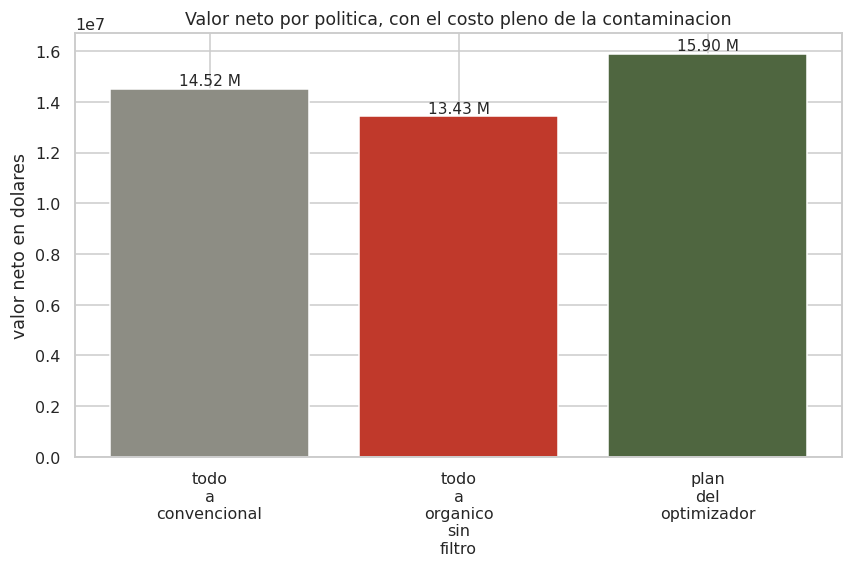

In [24]:
# Descomposicion del costo por quintal contaminado que llega a embarcar.
# La suma reproduce LAMBDA_RIESGO, que es el mismo costo que pondera la
# funcion objetivo del optimizador.
COSTO_PENALIZACION_QQ = 50.0
COSTO_ARRASTRE_CONTENEDOR_QQ = 130.0
COSTO_CERTIFICACION_QQ = 80.0
COSTO_CONTAMINACION_QQ = (
    COSTO_PENALIZACION_QQ + COSTO_ARRASTRE_CONTENEDOR_QQ + COSTO_CERTIFICACION_QQ
)

assert COSTO_CONTAMINACION_QQ == LAMBDA_RIESGO, (
    "el costo de evaluacion debe coincidir con el que optimiza el solver"
)

qq_total = plan["peso_quintales"].sum()
contaminados = plan["lote_contaminado"] == 1
qq_contaminado_total = plan.loc[contaminados, "peso_quintales"].sum()
qq_contaminado_exportado = plan.loc[
    contaminados & seleccion, "peso_quintales"
].sum()


def valorar(qq_organico, qq_organico_contaminado, costo=COSTO_CONTAMINACION_QQ):
    bruto = qq_organico * PRECIO_ORGANICO + (qq_total - qq_organico) * PRECIO_CONVENCIONAL
    return bruto - qq_organico_contaminado * costo


print(f"costo por quintal contaminado embarcado: US$ {COSTO_CONTAMINACION_QQ:.0f}")
print(f"  penalizacion directa      {COSTO_PENALIZACION_QQ:>6.0f}")
print(f"  arrastre del contenedor   {COSTO_ARRASTRE_CONTENEDOR_QQ:>6.0f}")
print(f"  riesgo de certificacion   {COSTO_CERTIFICACION_QQ:>6.0f}")
print()


politicas = pd.DataFrame(
    [
        {
            "politica": "todo a convencional",
            "qq_organico": 0.0,
            "qq_contaminado_embarcado": 0.0,
            "costo_contaminacion_usd": 0.0,
            "valor_neto_usd": valorar(0.0, 0.0),
        },
        {
            "politica": "todo a organico sin filtro",
            "qq_organico": qq_total,
            "qq_contaminado_embarcado": qq_contaminado_total,
            "costo_contaminacion_usd": qq_contaminado_total * COSTO_CONTAMINACION_QQ,
            "valor_neto_usd": valorar(qq_total, qq_contaminado_total),
        },
        {
            "politica": "plan del optimizador",
            "qq_organico": quintales_org,
            "qq_contaminado_embarcado": qq_contaminado_exportado,
            "costo_contaminacion_usd": qq_contaminado_exportado * COSTO_CONTAMINACION_QQ,
            "valor_neto_usd": valorar(quintales_org, qq_contaminado_exportado),
        },
    ]
).set_index("politica")

politicas["diferencia_vs_convencional"] = (
    politicas["valor_neto_usd"] - politicas.loc["todo a convencional", "valor_neto_usd"]
)

print(politicas.round(0).to_string())
print()
mejor = politicas["valor_neto_usd"].idxmax()
ventaja = (
    politicas.loc["plan del optimizador", "valor_neto_usd"]
    - politicas.loc["todo a organico sin filtro", "valor_neto_usd"]
)
print(f"politica de mayor valor neto: {mejor}")
print(f"ventaja del plan frente a exportar todo sin filtrar: US$ {ventaja:,.0f}")
print(f"contaminacion evitada en el contenedor: "
      f"{qq_contaminado_total - qq_contaminado_exportado:,.0f} quintales")

# Sensibilidad. A partir de que costo por quintal contaminado deja de
# convenir exportar todo sin filtrar.
delta_qq_organico = qq_total - quintales_org
delta_qq_contaminado = qq_contaminado_total - qq_contaminado_exportado
costo_indiferencia = (
    delta_qq_organico * (PRECIO_ORGANICO - PRECIO_CONVENCIONAL) / delta_qq_contaminado
)
print()
print(f"costo de indiferencia: US$ {costo_indiferencia:,.0f} por quintal contaminado")
print("  Por debajo de ese costo conviene exportar todo sin filtrar; por "
      "encima, conviene el plan.")
print(f"  El costo asumido es US$ {COSTO_CONTAMINACION_QQ:.0f}, "
      f"{'por encima' if COSTO_CONTAMINACION_QQ > costo_indiferencia else 'por debajo'} "
      "del punto de indiferencia.")

sensibilidad = pd.DataFrame(
    [
        {
            "costo_qq_contaminado": c,
            "valor_todo_organico": valorar(qq_total, qq_contaminado_total, c),
            "valor_plan": valorar(quintales_org, qq_contaminado_exportado, c),
        }
        for c in [50, 100, 150, 200, 260, 350, 500]
    ]
).set_index("costo_qq_contaminado")
sensibilidad["gana_el_plan"] = (
    sensibilidad["valor_plan"] > sensibilidad["valor_todo_organico"]
)
print()
print(sensibilidad.round(0).to_string())
sensibilidad.to_csv(RESULTADOS / "optimizacion" / "sensibilidad_costo.csv")

politicas.to_csv(RESULTADOS / "optimizacion" / "comparacion_politicas.csv")

fig, eje = plt.subplots(figsize=(9, 5))
colores = [PALETA[4], PALETA[1], PALETA[0]]
eje.bar(range(len(politicas)), politicas["valor_neto_usd"], color=colores)
eje.set_xticks(range(len(politicas)))
eje.set_xticklabels([t.replace(" ", chr(10)) for t in politicas.index])
eje.set_ylabel("valor neto en dolares")
eje.set_title("Valor neto por politica, con el costo pleno de la contaminacion")
for i, v in enumerate(politicas["valor_neto_usd"]):
    eje.text(i, v, f"{v/1e6:.2f} M", ha="center", va="bottom", fontsize=10)
plt.savefig(RESULTADOS / "optimizacion" / "comparacion_politicas.png")
plt.show()

### 12.2 Frontera de tolerancia

La tolerancia del contenedor no es un dato tecnico sino una clausula
comercial. Recorrerla muestra cuanto volumen organico se puede colocar
para cada nivel de riesgo aceptado, y donde deja de mandar la restriccion
para pasar a mandar la economia del propio lote.

 alfa  estado  lotes_organico  quintales_organico  riesgo_realizado  contaminados_exportados  valor_usd
 0.01 Optimal               0                 0.0            0.0000                        0 14517264.0
 0.02 Optimal               0                 0.0            0.0000                        0 14517264.0
 0.03 Optimal               0                 0.0            0.0000                        0 14517264.0
 0.05 Optimal             270             37340.0            0.0500                       15 16384264.0
 0.08 Optimal             355             48671.7            0.0800                       33 16950849.0
 0.12 Optimal             411             57938.4            0.0972                       46 17414184.0
 0.20 Optimal             411             57938.4            0.0972                       46 17414184.0


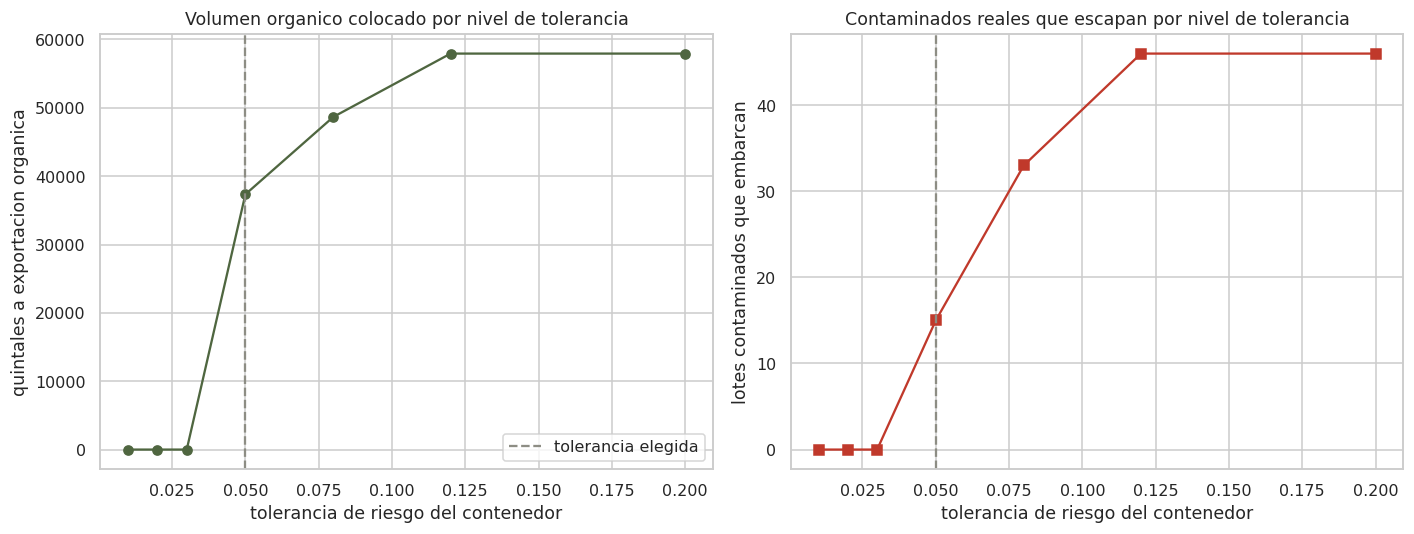

In [25]:
frontera = []
for alfa in [0.01, 0.02, 0.03, 0.05, 0.08, 0.12, 0.20]:
    p_alfa, plan_alfa, _ = resolver_segregacion(alfa)
    sel = plan_alfa["exporta_organico"] == 1
    qq = plan_alfa.loc[sel, "peso_quintales"].sum()
    frontera.append({
        "alfa": alfa,
        "estado": pulp.LpStatus[p_alfa.status],
        "lotes_organico": int(sel.sum()),
        "quintales_organico": qq,
        "riesgo_realizado": (
            (plan_alfa.loc[sel, "p_contaminado"] * plan_alfa.loc[sel, "peso_quintales"]).sum()
            / max(qq, 1e-9)
        ),
        "contaminados_exportados": int(plan_alfa.loc[sel, "lote_contaminado"].sum()),
        "valor_usd": qq * PRECIO_ORGANICO
        + (plan_alfa["peso_quintales"].sum() - qq) * PRECIO_CONVENCIONAL,
    })

frontera = pd.DataFrame(frontera)
print(frontera.round(4).to_string(index=False))
frontera.to_csv(RESULTADOS / "optimizacion" / "frontera_tolerancia.csv", index=False)

fig, ejes = plt.subplots(1, 2, figsize=(13, 5))

ejes[0].plot(frontera["alfa"], frontera["quintales_organico"],
             marker="o", color=PALETA[0])
ejes[0].axvline(ALFA_CONTENEDOR, ls="--", color=PALETA[4], label="tolerancia elegida")
ejes[0].set_xlabel("tolerancia de riesgo del contenedor")
ejes[0].set_ylabel("quintales a exportacion organica")
ejes[0].set_title("Volumen organico colocado por nivel de tolerancia")
ejes[0].legend()

ejes[1].plot(frontera["alfa"], frontera["contaminados_exportados"],
             marker="s", color=PALETA[1])
ejes[1].axvline(ALFA_CONTENEDOR, ls="--", color=PALETA[4])
ejes[1].set_xlabel("tolerancia de riesgo del contenedor")
ejes[1].set_ylabel("lotes contaminados que embarcan")
ejes[1].set_title("Contaminados reales que escapan por nivel de tolerancia")

plt.tight_layout()
plt.savefig(RESULTADOS / "optimizacion" / "frontera_tolerancia.png")
plt.show()

In [26]:
# Archivo final de decisiones por lote de inferencia.
plan_salida = plan.copy()
plan_salida["decision"] = np.where(
    plan_salida["exporta_organico"] == 1, "EXPORTACION_ORGANICA", "SEGREGAR_CONVENCIONAL"
)

def motivo(fila):
    if fila["exporta_organico"] == 1:
        return "cumple tolerancia de riesgo y no esta en zona de cuarentena"
    if fila["en_cuarentena"] == 1:
        return "cuarentena espacial: finca foco o colindante a un foco"
    if fila["p_contaminado"] >= (PRECIO_ORGANICO - PRECIO_CONVENCIONAL) / LAMBDA_RIESGO:
        return "riesgo esperado supera la diferencia de precio del lote"
    return "excluida para no romper la tolerancia agregada del contenedor"

plan_salida["motivo"] = plan_salida.apply(motivo, axis=1)
plan_salida["valor_asignado_usd"] = np.where(
    plan_salida["exporta_organico"] == 1,
    plan_salida["peso_quintales"] * PRECIO_ORGANICO,
    plan_salida["peso_quintales"] * PRECIO_CONVENCIONAL,
)
plan_salida["decil_riesgo"] = pd.qcut(
    plan_salida["p_contaminado"].rank(method="first"), 10, labels=range(10, 0, -1)
).astype(int)

columnas_salida = [
    "lote_id", "finca_id", "empresa_exportadora", "peso_quintales",
    "destino_previsto", "p_contaminado", "decil_riesgo", "alerta_modelo",
    "en_cuarentena", "decision", "motivo", "valor_asignado_usd",
    "lote_contaminado",
]
plan_salida = plan_salida[columnas_salida].sort_values(
    "p_contaminado", ascending=False
)

ruta_plan = RESULTADOS / "optimizacion" / "decisiones_por_lote.csv"
plan_salida.to_csv(ruta_plan, index=False)

print(f"guardado en {ruta_plan.relative_to(RAIZ)}  ({len(plan_salida)} lotes)")
print()
print("reparto de decisiones por motivo")
print(plan_salida.groupby(["decision", "motivo"]).size().to_string())
print()
print("primeras filas del plan, ordenadas por riesgo")
print(plan_salida.head(8).to_string(index=False))

guardado en resultados/optimizacion/decisiones_por_lote.csv  (636 lotes)

reparto de decisiones por motivo
decision               motivo                                                       
EXPORTACION_ORGANICA   cumple tolerancia de riesgo y no esta en zona de cuarentena      270
SEGREGAR_CONVENCIONAL  cuarentena espacial: finca foco o colindante a un foco           132
                       excluida para no romper la tolerancia agregada del contenedor    141
                       riesgo esperado supera la diferencia de precio del lote           93

primeras filas del plan, ordenadas por riesgo
lote_id finca_id empresa_exportadora  peso_quintales destino_previsto  p_contaminado  decil_riesgo  alerta_modelo  en_cuarentena              decision                                                 motivo  valor_asignado_usd  lote_contaminado
L001687    F0047          Cenfrocafe           124.8   Estados_Unidos            1.0             1              1              1 SEGREGAR_CONVENCIONA

## 13. Guardado de resultados

Se persiste todo lo que hace falta para reproducir la corrida y para
desplegar el modelo: las metricas de las tres etapas, la lista de variables
seleccionadas en cada una, los objetos entrenados y el plan de decision.

El recolector de basura se invoca al final para liberar las estructuras
intermedias, que es la practica que el enunciado pide cuando se trabaja en
memoria con pandas.

In [27]:
import joblib

comparativa.to_csv(RESULTADOS / "modelo" / "metricas_por_etapa.csv")
metricas_calibracion.to_csv(RESULTADOS / "modelo" / "metricas_calibracion.csv")
importancia_shap.to_frame("shap_medio_absoluto").to_csv(
    RESULTADOS / "modelo" / "importancia_shap.csv"
)
iv_numericas.to_frame("valor_informacion").to_csv(
    RESULTADOS / "modelo" / "valor_informacion_numericas.csv"
)
iv_categoricas.to_frame("valor_informacion").to_csv(
    RESULTADOS / "modelo" / "valor_informacion_categoricas.csv"
)

seleccion_variables = {
    "candidatas_iniciales": VARIABLES,
    "first_train": VARIABLES_E1,
    "second_train": VARIABLES_E2,
    "third_train": VARIABLES_E3,
    "descartadas_sin_varianza": sin_varianza,
    "descartadas_correlacion": sorted(descartadas_correlacion),
    "categoricas_vetadas_por_negocio": [
        c for c in CATEGORICAS
        if not CRITERIO_NEGOCIO[c][0] and iv_categoricas[c] >= IV_MINIMO
    ],
}
(RESULTADOS / "modelo" / "variables_seleccionadas.json").write_text(
    json.dumps(seleccion_variables, indent=2, ensure_ascii=False), encoding="utf-8"
)

artefacto = {
    "modelo": modelo_final,
    "calibrador": isotonica,
    "escalador": escalador,
    "variables": VARIABLES_FINALES,
    "mapas_categorias": mapas_categorias,
    "umbral_operativo": float(UMBRAL_OPERATIVO),
    "parametros": PARAMETROS,
    "multietiqueta": multietiqueta,
    "etiquetas": ETIQUETAS,
}
joblib.dump(artefacto, RESULTADOS / "modelo" / "artefacto_cafetrace.joblib")

resumen_final = {
    "semilla": SEMILLA,
    "lotes_totales": int(len(datos)),
    "tasa_contaminacion": float(datos[OBJETIVO].mean()),
    "particion": {
        "entrenamiento": int(len(entrena)),
        "calibracion": int(len(calibra)),
        "prueba": int(len(prueba)),
    },
    "variables_finales": VARIABLES_FINALES,
    "umbral_operativo": float(UMBRAL_OPERATIVO),
    "metricas_prueba": {
        "f1": float(f1_score(y_prueba, y_pred)),
        "recall": float(recall_score(y_prueba, y_pred)),
        "precision": float(precision_score(y_prueba, y_pred)),
        "auc": float(roc_auc_score(y_prueba, p_prueba_calibrada)),
        "average_precision": float(average_precision_score(y_prueba, p_prueba_calibrada)),
        "brier_calibrado": float(brier_score_loss(y_prueba, p_prueba_calibrada)),
        "ks": float(ks),
        "lift_primer_decil": float(tabla.loc[1, "lift"]),
        "captura_tres_deciles": float(tabla.loc[3, "captura_acumulada"]),
        "falsos_negativos": int(fn),
        "falsos_positivos": int(fp),
    },
    "optimizacion": {
        "alfa": ALFA_CONTENEDOR,
        "lambda": LAMBDA_RIESGO,
        "lotes_exportados": int(seleccion.sum()),
        "lotes_totales_inferencia": int(len(plan)),
        "quintales_exportados": float(quintales_org),
        "riesgo_realizado": float(riesgo_realizado),
        "contaminados_exportados": int(plan.loc[seleccion, "lote_contaminado"].sum()),
        "valor_plan_usd": float(valor_plan),
        "fincas_en_cuarentena": int(len(en_cuarentena)),
    },
}
(RESULTADOS / "resumen_ejecucion.json").write_text(
    json.dumps(resumen_final, indent=2, ensure_ascii=False), encoding="utf-8"
)

print("archivos escritos en resultados")
for ruta in sorted(RESULTADOS.rglob("*")):
    if ruta.is_file():
        print(f"  {ruta.relative_to(RESULTADOS)}  ({ruta.stat().st_size / 1024:.1f} kB)")

del valores_shap, correlacion, distancias_m
gc.collect()
print()
print("memoria intermedia liberada")

archivos escritos en resultados
  eda/correlacion.png  (126.4 kB)
  eda/resumen_objetivo.png  (112.8 kB)
  eda/separacion_univariada.png  (75.0 kB)
  modelo/analisis_deciles.csv  (1.0 kB)
  modelo/analisis_deciles.png  (86.6 kB)
  modelo/artefacto_cafetrace.joblib  (1325.7 kB)
  modelo/calibracion.png  (72.9 kB)
  modelo/comparativa_etapas.png  (69.8 kB)
  modelo/frontera_umbral.png  (40.0 kB)
  modelo/importancia_shap.csv  (1.4 kB)
  modelo/importancia_shap.png  (99.9 kB)
  modelo/mapas_categorias.json  (0.7 kB)
  modelo/metricas_calibracion.csv  (0.2 kB)
  modelo/metricas_multietiqueta.csv  (0.5 kB)
  modelo/metricas_por_etapa.csv  (0.5 kB)
  modelo/multietiqueta.png  (25.6 kB)
  modelo/shap_dispersion.png  (107.2 kB)
  modelo/valor_informacion_categoricas.csv  (0.2 kB)
  modelo/valor_informacion_numericas.csv  (0.5 kB)
  modelo/variables_seleccionadas.json  (2.9 kB)
  optimizacion/comparacion_politicas.csv  (0.3 kB)
  optimizacion/comparacion_politicas.png  (32.7 kB)
  optimizacion/

## Cierre

Lo que queda operativo al terminar este cuaderno:

* Un clasificador entrenado sobre ocho variables, con probabilidades
  calibradas y un umbral elegido con prioridad de recall.
* Un modelo multietiqueta que anticipa cual de los cuatro kits del panel
  tiene mas probabilidad de dar positivo, lo que permite ordenar el gasto
  de kits.
* Un plan de segregacion por lote, con el motivo de cada decision, listo
  para que el supervisor lo ejecute en el centro de acopio.

El informe tecnico con la lectura detallada de cada etapa esta en el
archivo report.md de la raiz del proyecto.